<a href="https://colab.research.google.com/github/Hafeez1002/QCES/blob/main/Copy_of_20251207_Draft_Analyser_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# THE DIFFERENCE BETWEEN THIS AND V1 IS THAT A IS NOT FLEXIBLE


# Imports

In [ ]:
# Basic Analyser
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving outdoor_ref_cam_co2_241125_301125.csv to outdoor_ref_cam_co2_241125_301125.csv
Saving outdoor_ref_cam_co2_141025_231125.csv to outdoor_ref_cam_co2_141025_231125.csv
Saving tacolneston_185m_co2.csv to tacolneston_185m_co2.csv
Saving Complete Set.csv to Complete Set.csv


# Fonts

In [ ]:
# Set font for labels in coming figures
font4 = {'family': 'sans-serif',
          'color':  'black',
          'weight': 'normal',
          'size': 4,
          }

# Set font for labels in coming figures
font8 = {'family': 'sans-serif',
          'color':  'black',
          'weight': 'normal',
          'size': 8,
          }

# Set font for labels in coming figures
font10 = {'family': 'sans-serif',
          'color':  'black',
          'weight': 'normal',
          'size': 10,
          }

# Set font for labels in coming figures
font12 = {'family': 'sans-serif',
          'color':  'black',
          'weight': 'normal',
          'size': 12,
          }

# Set font for labels in coming figures
font16 = {'family': 'sans-serif',
          'color':  'black',
          'weight': 'normal',
          'size': 16,
          }

# Set font for labels in coming figures
font20 = {'family': 'sans-serif',
          'color':  'black',
          'weight': 'normal',
          'size': 20,
          }

# DATA IMPORT AND SETUP / DOWN CLEANING FUNCTION

data = raw original csv

data_trim removes unnecessary columns

data_clean removes the regions around setup and setdown

In [ ]:
data_clean

NameError: name 'data_clean' is not defined

In [ ]:
### OWN Data Import
datapath = '/content/Complete Set.csv'
#datapath = '/content/drive/MyDrive/Y4/QCES/EDAA/Group J/AirScentData.csv'

data = pd.read_csv(datapath)
data_trim = data[["Location ID","Local Date/Time", "PM2.5 (μg/m³) raw", "CO2 (ppm) raw", "Temperature (°C) raw", "Humidity (%) raw", "TVOC (ppb)", "TVOC index", "NOX index" ]].copy()
data_trim["Local Date/Time"] = pd.to_datetime(data_trim["Local Date/Time"])

data_trim['CO2 (ppm) calib'] = data_trim['CO2 (ppm) raw'] * 1.0511 + 8.5049
# 1.0511 × raw_CO2 + 8.5049



def cleaning(threshold, blast_radius, data_trim_input):                     # Cleaning receives: Time threshold (definition of a gap)
                                                                            # Blast radius is how many data points either side of the big gaps
  data_trim = data_trim_input.copy()                                        # Copying to not break things (hopefully)
  data_trim["Time Gap"] = data_trim["Local Date/Time"].diff()               # Takes the time gap between datapoints

  if not data_trim.empty:
      data_trim.loc[data_trim.index[0], "Time Gap"] = pd.Timedelta(0)       # Sets the first value of time gap to 0 (because it was N/A)

  data_trim["Time Gap"] = data_trim["Time Gap"].dt.total_seconds()          # Timedelta --> Float64


  mask = data_trim['Time Gap'] < threshold                                  # This mask identifies time gaps rel to the threshold when you call the func

  # Get the *actual index labels* of the rows that meet the condition
  problematic_indices = data_trim[mask].index.to_numpy()                    # Pulls the indices

  # Generate 'blast radius' indices around each problematic index
  blastee_indices = []
  for idx in problematic_indices:

    hits = np.arange(idx - blast_radius, idx + blast_radius + 1)            # Blasting
    blastee_indices.extend(hits)

  # Convert to unique array and filter for indices that actually exist in the DataFrame
  blastee_indices = np.unique(blastee_indices)
  existing_indices_to_drop = blastee_indices[np.isin(blastee_indices, data_trim.index)]

  # Drop the rows from the DataFrame
  data_clean = data_trim.drop(index=existing_indices_to_drop)

  return data_clean

data_clean = cleaning(-3600,30,data_trim)

In [ ]:
### Chemistry Department data

data_chemA = pd.read_csv('/content/outdoor_ref_cam_co2_141025_231125.csv')
data_chemB = pd.read_csv('/content/outdoor_ref_cam_co2_241125_301125.csv')
data_chem = pd.concat([data_chemA, data_chemB])

# This is ugly but effective solution to make the functions keep working
data_chem["Local Date/Time"] = pd.to_datetime(data_chem["datetime_utc"] )
data_chem['CO2 (ppm) calib'] = data_chem['ref_cam_outdoor_co2_ppm']

In [ ]:
### Rural data

data_rural = pd.read_csv('/content/tacolneston_185m_co2.csv')
data_rural

# This is ugly but effective solution to make the functions keep working
data_rural["Local Date/Time"] = pd.to_datetime(data_rural.loc[:,'time'])

data_rural[' co2_C'] = data_rural[' co2_C'].str.replace(',', '').astype(float)

data_rural['CO2 (ppm) calib'] = pd.to_numeric(data_rural.loc[:,' co2_C'])


# DATA SUMMARY

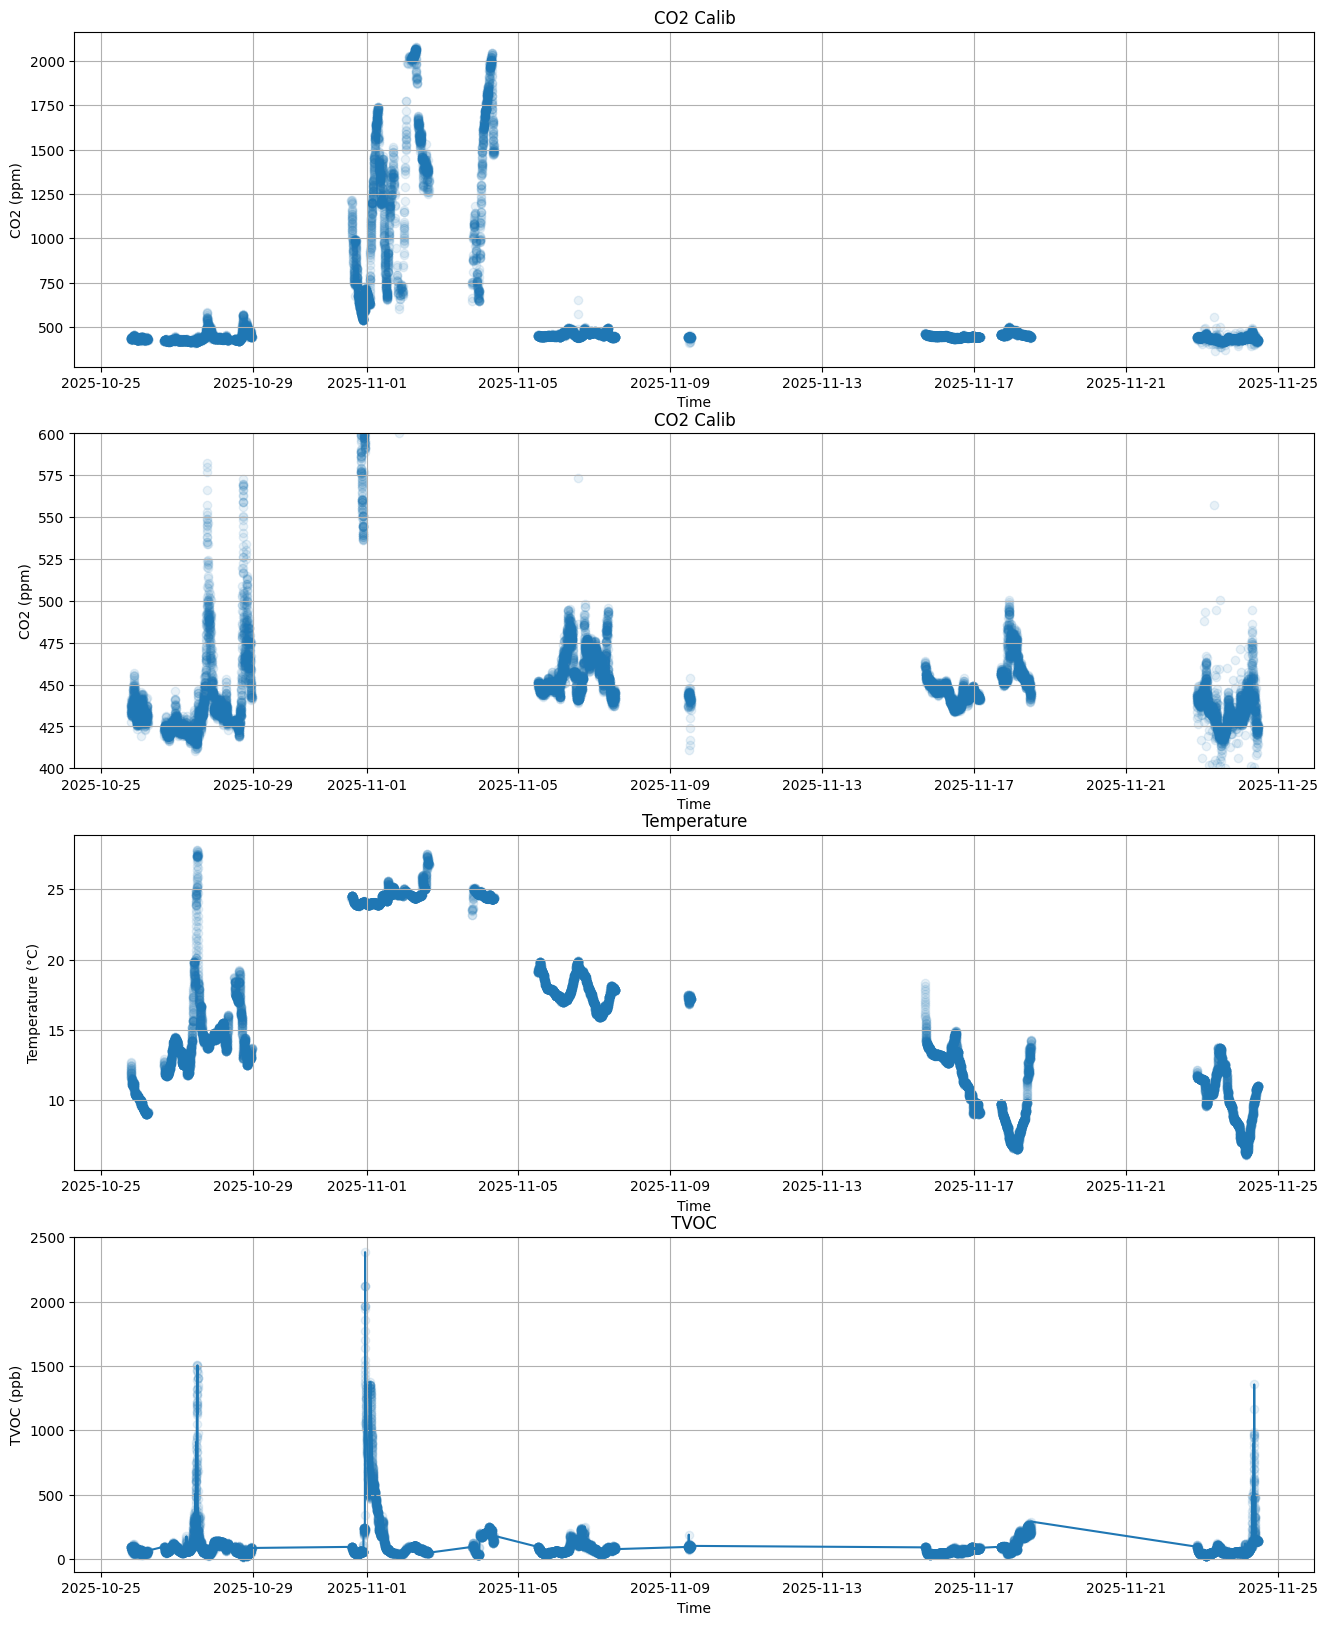

In [ ]:
### Data Summary
data_clean = cleaning(-3600,30,data_trim)

fig, axs = plt.subplots(4, 1, figsize=(16, 20))
ax0, ax1, ax2, ax3 = axs


#ax0.plot(data_clean['Local Date/Time'], data_clean['CO2 (ppm) calib'])
ax0.scatter(data_clean['Local Date/Time'], data_clean['CO2 (ppm) calib'], alpha = 0.1)
ax0.grid()
ax0.set_ylabel('CO2 (ppm)')
ax0.set_xlabel('Time')
ax0.set_title('CO2 Calib')


#plot(data_clean['Local Date/Time'], data_clean['CO2 (ppm) calib'])
ax1.scatter(data_clean['Local Date/Time'], data_clean['CO2 (ppm) calib'], alpha = 0.1)
ax1.grid()
ax1.set_ylabel('CO2 (ppm)')
ax1.set_xlabel('Time')
ax1.set_title('CO2 Calib')
ax1.set_ylim(400,600)

#ax2.plot(data_clean['Local Date/Time'], data_clean['Temperature (°C) raw'])
ax2.scatter(data_clean['Local Date/Time'], data_clean['Temperature (°C) raw'], alpha = 0.1)
ax2.grid()
ax2.set_ylabel('Temperature (°C)')
ax2.set_xlabel('Time')
ax2.set_title('Temperature')

ax3.plot(data_clean['Local Date/Time'], data_clean['TVOC (ppb)'])
ax3.scatter(data_clean['Local Date/Time'], data_clean['TVOC (ppb)'], alpha = 0.1)
ax3.grid()
ax3.set_ylabel('TVOC (ppb)')
ax3.set_xlabel('Time')
ax3.set_title('TVOC')

plt.show()

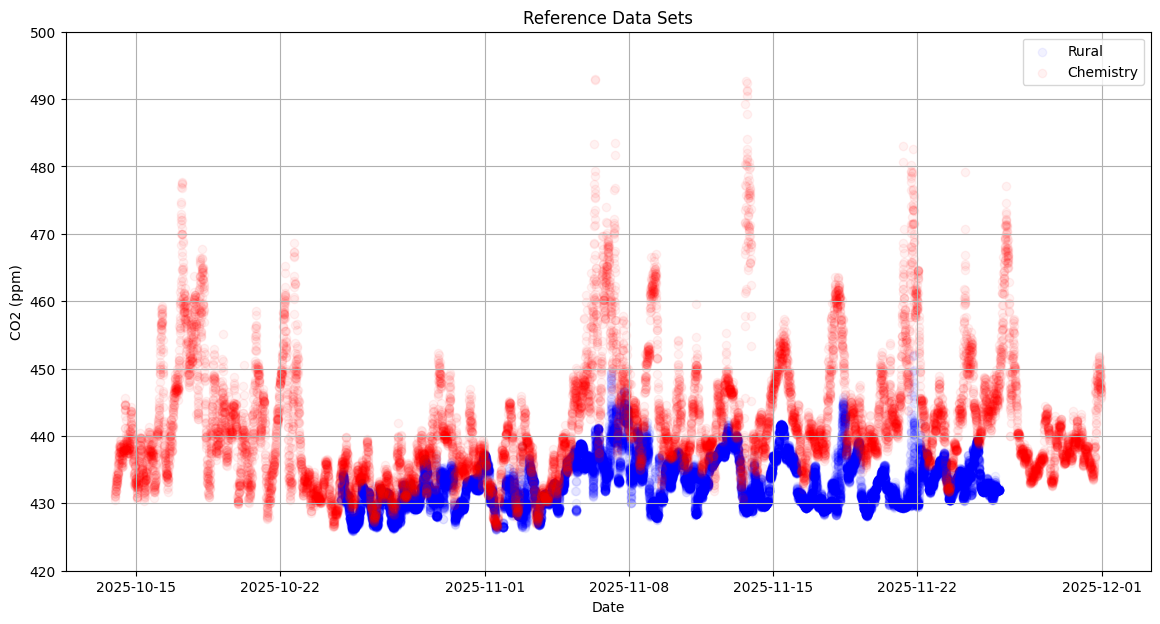

In [ ]:
## Reference data

plt.figure(figsize = (14,7))

plt.scatter(data_rural.loc[:,'Local Date/Time'], data_rural.loc[:,'CO2 (ppm) calib'], alpha = 0.05, color = 'b')
plt.scatter(data_chem.loc[:,'Local Date/Time'], data_chem.loc[:,'CO2 (ppm) calib'], alpha = 0.05, color = 'r')
plt.grid()
plt.ylim(420, 500)
plt.legend(['Rural', 'Chemistry'])
plt.title('Reference Data Sets')
plt.xlabel('Date')
plt.ylabel('CO2 (ppm)')

plt.show()


#plt.figure(figsize = (14,7))
#
#plt.scatter(data_rural.loc[:,'Local Date/Time'],  data_chem.loc[:,'CO2 (ppm) calib'] - data_rural.loc[:,'CO2 (ppm) calib'], alpha = 0.1, color = 'b')
#plt.grid()
#plt.title('Difference between Rural and Chemistry')
#plt.xlabel('Date')
#plt.ylabel('Diff CO2 (ppm)')
#
#
#
#plt.show()

# Plotter

In [ ]:
### Figure builder function
def plotterA(data_window, alpha):
    fig, axs = plt.subplots(2, 1, figsize=(16, 10))
    ax0, ax1 = axs

    # CO2 no ylim
    ax0.scatter(data_window['Local Date/Time'], data_window['CO2 (ppm) calib'], alpha = alpha)
    ax0.grid()
    ax0.set_ylabel('CO2 (ppm)')
    ax0.set_xlabel('Time')
    ax0.set_title('CO2 Calib')

    # CO2 with ylim
    ax1.scatter(data_window['Local Date/Time'], data_window['CO2 (ppm) calib'], alpha = alpha)
    ax1.grid()
    ax1.set_ylabel('CO2 (ppm)')
    ax1.set_xlabel('Time')
    ax1.set_title('CO2 Calib')
    ax1.set_ylim(400,525)



def plotterB(data_window, alpha):
    fig, axs = plt.subplots(4, 1, figsize=(16, 20))
    ax0, ax1, ax2, ax3 = axs

    # CO2 no ylim
    ax0.scatter(data_window['Local Date/Time'], data_window['CO2 (ppm) calib'], alpha = alpha)
    ax0.grid()
    ax0.set_ylabel('CO2 (ppm)')
    ax0.set_xlabel('Time')
    ax0.set_title('CO2 Calib')

    # CO2 with ylim
    ax1.scatter(data_window['Local Date/Time'], data_window['CO2 (ppm) calib'],  alpha = alpha)
    ax1.grid()
    ax1.set_ylabel('CO2 (ppm)')
    ax1.set_xlabel('Time')
    ax1.set_title('CO2 Calib')
    ax1.set_ylim(400,525)

    # Temp
    ax2.scatter(data_window['Local Date/Time'], data_window['Temperature (°C) raw'],  alpha = alpha)
    ax2.grid()
    ax2.set_ylabel('Temperature (°C)')
    ax2.set_xlabel('Time')
    ax2.set_title('Temperature')

    # TVOC
    ax3.plot(data_window['Local Date/Time'], data_window['TVOC (ppb)'])
    ax3.scatter(data_window['Local Date/Time'], data_window['TVOC (ppb)'],  alpha = alpha)
    ax3.grid()
    ax3.set_ylabel('TVOC (ppb)')
    ax3.set_xlabel('Time')
    ax3.set_title(f'TVOC {np.round(data_window['TVOC (ppb)'].mean(),2)}')
    ax3.set_ylim(0,300)

    plt.show()

# FUNCTION TO TAKE A DATA WINDOW FOR ANALYSIS

In [ ]:
### INSTRUCTIONS
#   RUN THIS CELL FIRST TO GRAB THE INDICES FOR YOUR CHOSEN TIME
#   TAKE THE START INDEX FOR THE NEXT CELL AND THE END INDEX IS THE ONE TO THE
#   LEFT OF IT IN THE PRINT OUT. I.E. NOT ADJACENT VALUES

#   E.G.      ends        [1214, 3348]
#             starts      [1213, 3347]
#             Then to get the windwow that starts at whatever time is printed
#             for 3347. start ind = 3347, end ind = 1214,
#             For start ind 1213, end ind = 0

#   THEN GO TO NEXT CELL

# It's a bit of a convulted piece of code but basically it works like this:
# It takes the original "data_trim" csv and finds the big gaps
# From this it finds indices for start and end
# These can be used in a loc call of data trim to set useful xlims
# It also finds according timestamps
# It also sets the basis about which blast radius is then applied
# Then it finds data within a window within data_clean. i.e without your end mems

def index_finder(data_trim, data_clean):
  data_trim["Time Gap"] = data_trim["Local Date/Time"].diff()               # Takes the time gap between datapoints

  if not data_trim.empty:
    data_trim.loc[data_trim.index[0], "Time Gap"] = pd.Timedelta(0)       # Sets the first value of time gap to 0 (because it was N/A)

  data_trim["Time Gap"] = data_trim["Time Gap"].dt.total_seconds()          # Timedelta --> Float64

  mask = data_trim['Time Gap'] < -3600

  end_indices = data_trim[mask].index.to_numpy()
  start_indices = end_indices - 1

  print('end indicies', end_indices)
  print('start indicies', start_indices)
  print('')
  print('Start Times')
  print(data_trim.loc[start_indices, 'Local Date/Time'])


  data_trim.loc[start_indices, 'Local Date/Time']
  return start_indices, end_indices

start_indices, end_indices = index_finder(data_trim, data_clean)

end indicies [ 2322  3536  5670  5842  8723  9372 11522 12214 14612 15345]
start indicies [ 2321  3535  5669  5841  8722  9371 11521 12213 14611 15344]

Start Times
2321    2025-11-22 20:22:04
3535    2025-11-17 16:16:50
5669    2025-11-15 16:37:36
5841    2025-11-09 10:40:30
8722    2025-11-05 11:48:38
9371    2025-11-03 18:12:37
11521   2025-10-31 13:52:32
12213   2025-10-28 11:53:43
14611   2025-10-26 15:31:01
15344   2025-10-25 18:23:00
Name: Local Date/Time, dtype: datetime64[ns]


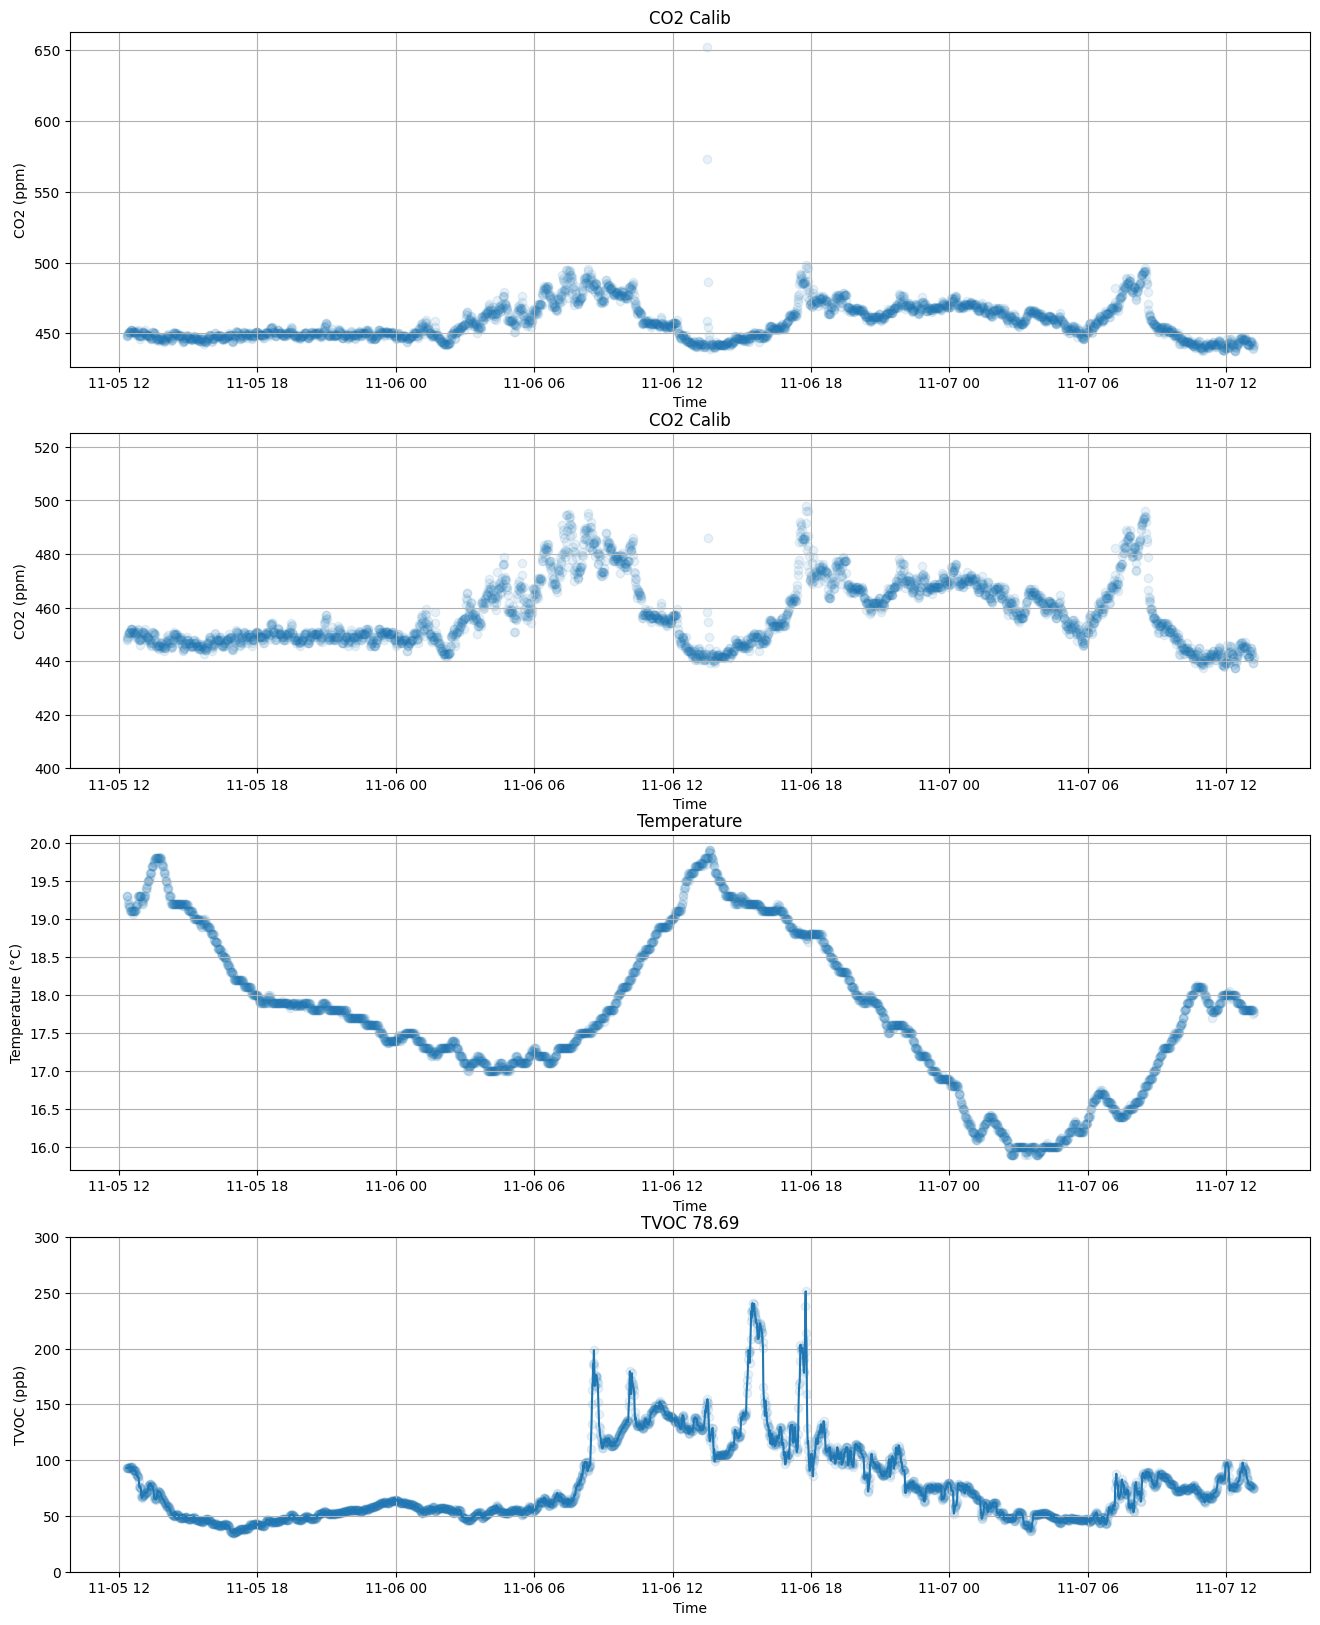

In [ ]:
def data_window(data_trim, data_clean, data_chem, data_rural, start_ind, end_ind,graph):
  # Instructions on getting you start_ind and end_ind are above.
  # Should be one number each. end_ind ought to be smaller

  # For 'graph'. Enter 1 if you want a graph. Enter anything else if you don't

  tstart = data_trim.loc[start_ind, 'Local Date/Time']          # Pulls a start time
  tend   = data_trim.loc[end_ind, 'Local Date/Time']            # Pulls a end time

  startmask = data_clean.loc[:,'Local Date/Time'] > tstart      #
  endmask   = data_clean.loc[:,'Local Date/Time'] < tend        #
  data_window = data_clean[startmask & endmask]                 #

  startmask     = data_chem.loc[:,'Local Date/Time'] > tstart   #
  endmask       = data_chem.loc[:,'Local Date/Time'] < tend     #
  chem_window   = data_chem[startmask & endmask]                #

  startmask     = data_rural.loc[:,'Local Date/Time'] > tstart  #
  endmask       = data_rural.loc[:,'Local Date/Time'] < tend    #
  rural_window   = data_rural[startmask & endmask]              #


  if graph == 1:
    plotterB(data_window, 0.1)

  #else:
    #print('No Graph')

  return data_window, chem_window, rural_window


Sidney_data, Sidney_chem, Sidney_rural = data_window(data_trim, data_clean, data_chem, data_rural, 8722, 5842, 1)

# FUNCTION TO INTERPOLATE DATA INTO CLEAN BINS

Objective of this function is to standardise datasets to common time axis, reducing noise and allowing for analysis

Function recieves:

dataset       - Data for binning

bin_minutes   - Duration in minutes

graph         - Do you want a graph. put 1

In [ ]:
def binner(dataset, bin_minutes, graph, align_bins=False):

  dataset               = dataset.sort_values('Local Date/Time')
  original_timestamps   = dataset['Local Date/Time']    # Collects the original Time pre interpolation
  original_co2_values   = dataset['CO2 (ppm) calib']    # Collects the original CO2 pre interpolation

  # Filter out NaN values for interpolation
  valid_indices             = original_co2_values.dropna().index
  original_timestamps_valid = original_timestamps.loc[valid_indices]
  original_co2_values_valid = original_co2_values.loc[valid_indices]

  unix_timestamps       = original_timestamps_valid.astype('int64') // 10**9      # Formats in Unix for numpy to do things. This is in ns so has the divide

  start_time            = unix_timestamps.min()
  end_time              = unix_timestamps.max()
  bin_size_seconds      = bin_minutes * 60

  if align_bins:
      start_dt = pd.to_datetime(start_time, unit='s')
      minute = start_dt.minute

      if minute < bin_minutes:
          minutes_to_subtract = minute
      else: # minute >= bin_minutes
          minutes_to_subtract = minute - bin_minutes

      start_dt_aligned = start_dt.replace(minute=minute - minutes_to_subtract, second=0, microsecond=0, nanosecond=0)
      start_time = int(start_dt_aligned.timestamp()) # Convert back to Unix timestamp

  new_unix_timestamps   = np.arange(start_time, end_time + bin_size_seconds, bin_size_seconds)      # New stamps

  interpolated_co2_values = np.interp(new_unix_timestamps, unix_timestamps, original_co2_values_valid)    # Interpolated data

  interpolated_df = pd.DataFrame({
      'Local Date/Time': pd.to_datetime(new_unix_timestamps, unit='s'),
      'CO2 (ppm) calib': interpolated_co2_values
  })

  if graph == 1:
    fig, axs = plt.subplots(1, 1, figsize=(16, 5))
    ax0 = axs

    ax0.scatter(original_timestamps, original_co2_values, label = 'Original Data', color = 'b', alpha = 0.05)
    ax0.plot(interpolated_df['Local Date/Time'], interpolated_df['CO2 (ppm) calib'], label = f'Interpolated: Binsize = {bin_minutes} minutes', color = 'r', alpha = 0.6)
    ax0.grid()
    ax0.set_ylabel('CO2 (ppm)', fontdict = font16)
    ax0.set_xlabel('Time'     , fontdict = font16)
    ax0.set_title('Binner Result: CO2 Calib', fontdict = font20)
    ax0.legend()
    #ax0.set_ylim(425,525)

  #else:
  #  print('No Graph')

  return interpolated_df

,Local Date/Time,CO2 (ppm) calib
0,2025-11-05 12:05:00,447.864700
1,2025-11-05 12:10:00,447.864700
2,2025-11-05 12:15:00,447.864700
3,2025-11-05 12:20:00,447.864700
4,2025-11-05 12:25:00,450.536997
...,...,...
586,2025-11-07 12:55:00,442.439668
587,2025-11-07 13:00:00,441.558100
588,2025-11-07 13:05:00,444.244244
589,2025-11-07 13:10:00,440.267620


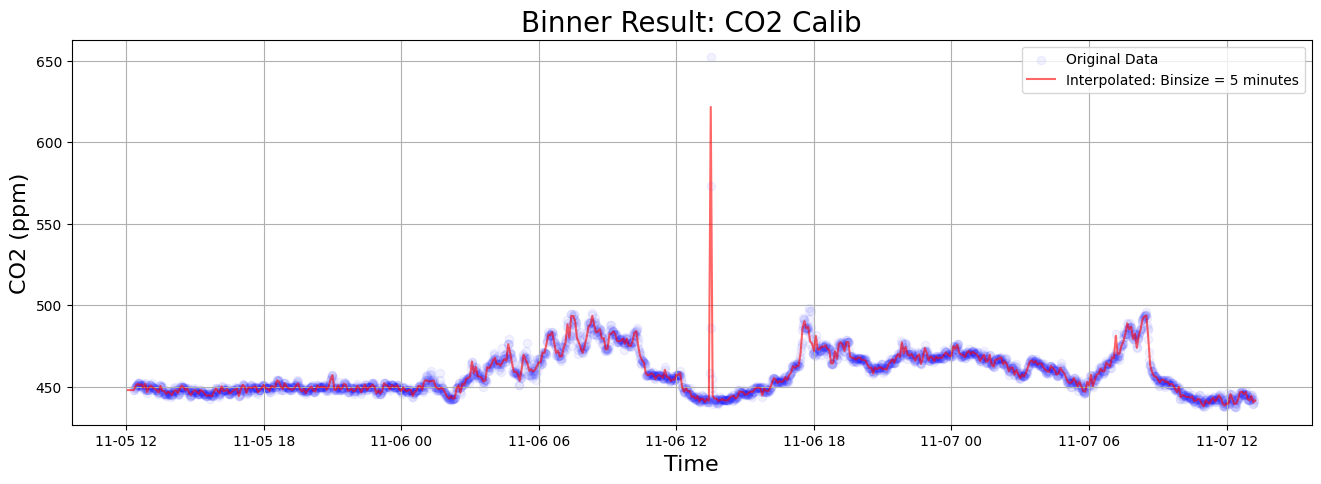

In [ ]:
binner(Sidney_data, 5, 1, align_bins=False)

# The Model

$$
[CO_2] = A + B(x)̇·  f(t) + C(x)̇·g(t) + d(x,t)
$$
Where:

1.   **A** is a base level constant
2.   **B(x)** and **C(x)** are functions of space only that describe an area's relative influence from biological cycles and traffic. Normalised against chemistry dept data
3.   **f(t)** and **g(t)** are functions of time only that describe in day size chunks the evolution of biological CO2 cycling and anthropogenic sources. f(t) is defined via an external dataset.

In this iteration of the model. f(t) and g(t) are understood not as pure bio or traffic signals but as linearly independent endmembers in a bio/traffic basis. f(t) is a background rural signal. g(t) represents the ADDITIONAL urban signal from traffic s.t. f(t) + g(t) give the structure of urban signals

4.   **d(x,t)** is the noise residual

Solving for B, C and d.

Fitting of A, B and C via minimisation d_average.
Least squares regression

$$
d(x,t) = [CO_2] - [A + B·  f(t) + C·g(t)]
$$
\
$$
Minimise \,\,\,\,\sum_i d(t_i)^2
$$

np.linalg.lstsq receives a coefficient matrix and a dataset. The dataset is our CO2 data at each site. The coefficient matrix is based the functional forms of A,B,C. For A it is a bunch of ones, for B and C it is based on f(t) and g(t) at each time.

# Building f(t) and g(t)

In [ ]:
def signal_extraction(chem_window, rural_window, bin_minutes, graph):
  interpolated_rural  = binner(rural_window, bin_minutes, 0, align_bins=True)
  interpolated_chem   = binner(chem_window, bin_minutes, 0, align_bins=True)

  signal_time        = interpolated_rural['Local Date/Time']

  rural_co2          = interpolated_rural['CO2 (ppm) calib']
  chem_co2           = interpolated_chem['CO2 (ppm) calib']

  rural_mean = np.mean(rural_co2)

  f_signal_co2 = rural_co2 - rural_mean
  g_signal_co2 = chem_co2 - f_signal_co2 - rural_mean

  f_signal = pd.DataFrame({'Local Date/Time': signal_time, 'f_signal': f_signal_co2})
  g_signal = pd.DataFrame({'Local Date/Time': signal_time, 'g_signal': g_signal_co2})

  f_signal = f_signal.dropna()
  g_signal = g_signal.dropna()

  if graph == 1:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.scatter(f_signal.loc[:, 'Local Date/Time'], f_signal.loc[:, 'f_signal'], color ='g', label = 'f signal')
    ax.scatter(g_signal.loc[:, 'Local Date/Time'], g_signal.loc[:, 'g_signal'], color ='r', label = 'g signal')
    ax.set_xlabel('Time', fontdict = font16)
    ax.set_ylabel('Signal CO2 (ppm)', fontdict = font16)
    ax.set_title('f(t) and g(t)', fontdict = font20)
    ax.grid()
    ax.legend()

  #else:
  #  print('No Graph')



  return signal_time, f_signal, g_signal, rural_mean

(0     2025-11-05 11:05:00
 1     2025-11-05 11:10:00
 2     2025-11-05 11:15:00
 3     2025-11-05 11:20:00
 4     2025-11-05 11:25:00
               ...        
 600   2025-11-07 13:05:00
 601   2025-11-07 13:10:00
 602   2025-11-07 13:15:00
 603   2025-11-07 13:20:00
 604   2025-11-07 13:25:00
 Name: Local Date/Time, Length: 605, dtype: datetime64[ns],
         Local Date/Time  f_signal
 0   2025-11-05 11:05:00 -2.011657
 1   2025-11-05 11:10:00 -2.011657
 2   2025-11-05 11:15:00 -2.011657
 3   2025-11-05 11:20:00 -2.011657
 4   2025-11-05 11:25:00 -2.011657
 ..                  ...       ...
 600 2025-11-07 13:05:00 -1.598657
 601 2025-11-07 13:10:00 -1.132657
 602 2025-11-07 13:15:00 -1.038657
 603 2025-11-07 13:20:00 -0.892657
 604 2025-11-07 13:25:00 -0.980657
 
 [605 rows x 2 columns],
         Local Date/Time  g_signal
 0   2025-11-05 11:05:00    12.435
 1   2025-11-05 11:10:00    12.435
 2   2025-11-05 11:15:00    12.435
 3   2025-11-05 11:20:00    12.435
 4   2025-11-05 11:25

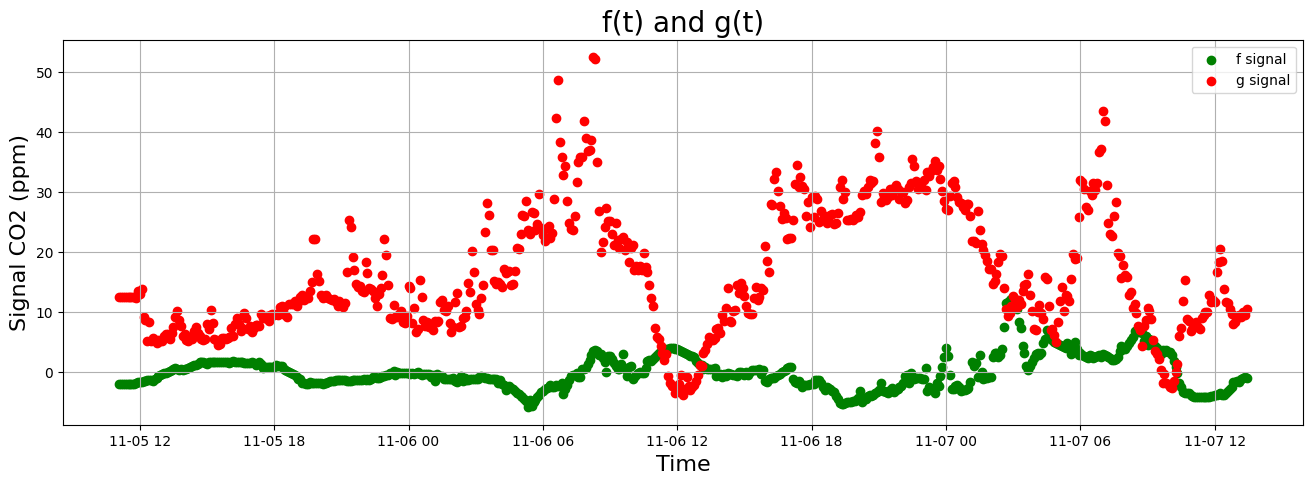

In [ ]:
signal_extraction(Sidney_chem, Sidney_rural , 5, 1)

RUN SUMMARY
[1.66212159 0.39408661]
2.5884036189956503
RUN SUMMARY
[0.47576538 1.24538366]
-0.553790268190356
RUN SUMMARY
[1.54117233 1.55645451]
-0.7533845790934893
RUN SUMMARY
[-0.03537452  1.25476769]
-0.9239287627572992
RUN SUMMARY
[1.53180089 1.17197547]
-2.7758554405299196
RUN SUMMARY
[-165.62299596  411.72925601]
-330.2453927311968
RUN SUMMARY
[ 26.69856427 103.40349566]
-424.9341938664782
RUN SUMMARY
[6.01740571 5.11675289]
1.4273309614154888
RUN SUMMARY
[1.87032167 2.77975809]
4.163099970219935
RUN SUMMARY
[-1.73909286  0.65864791]
-0.33316916446521344


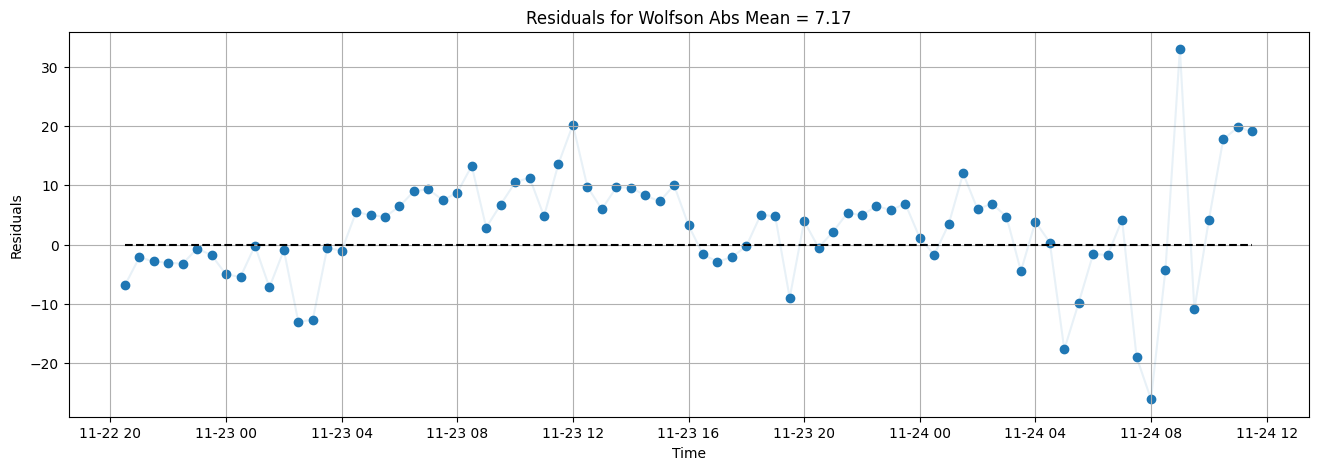

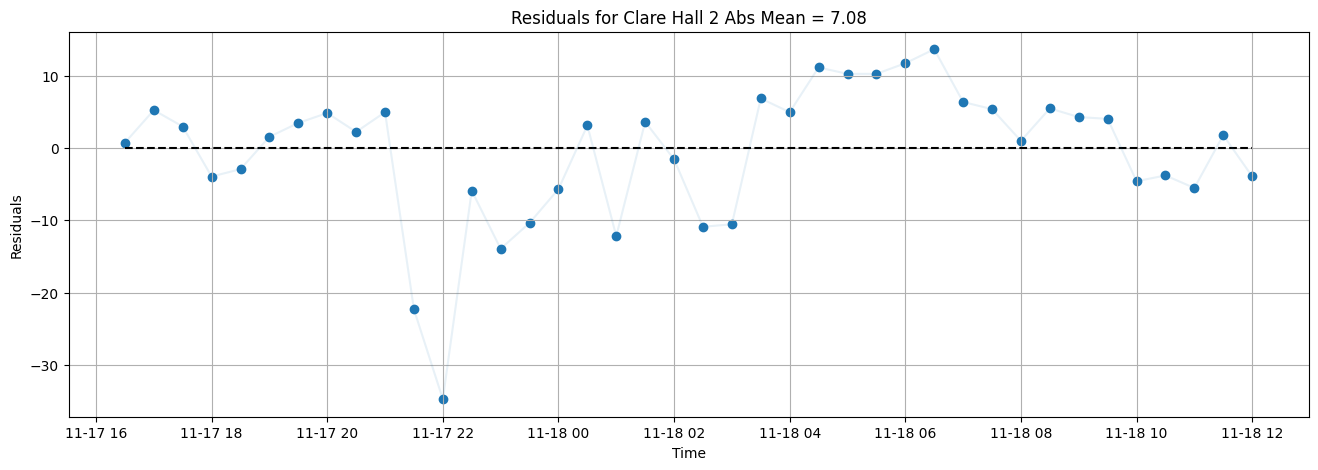

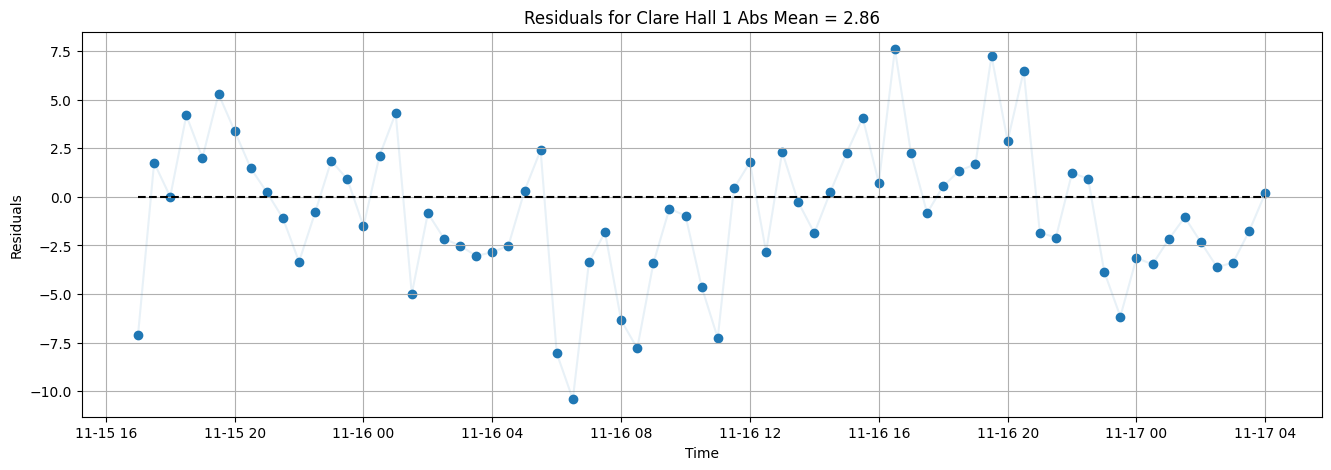

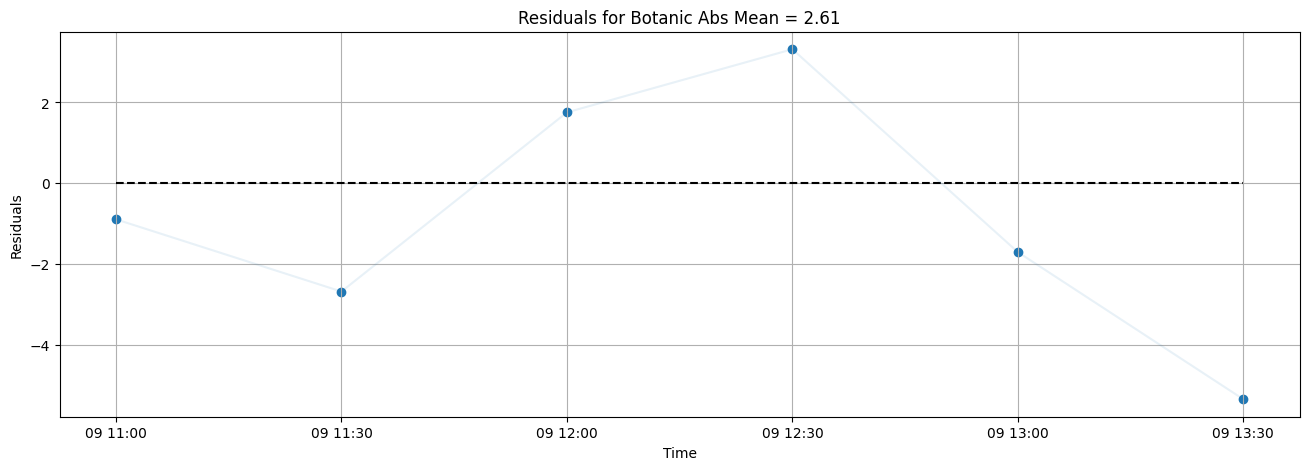

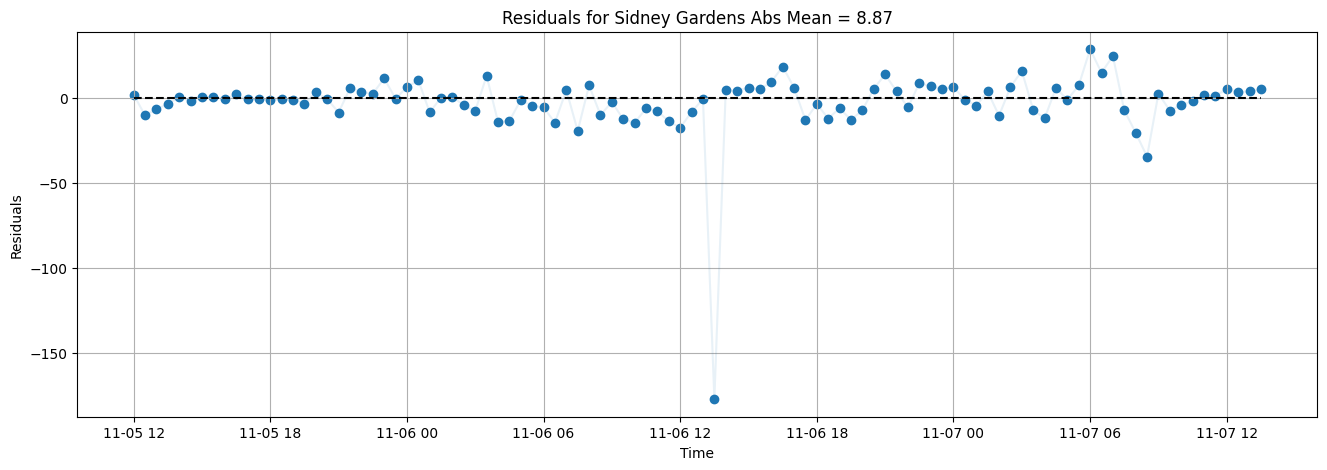

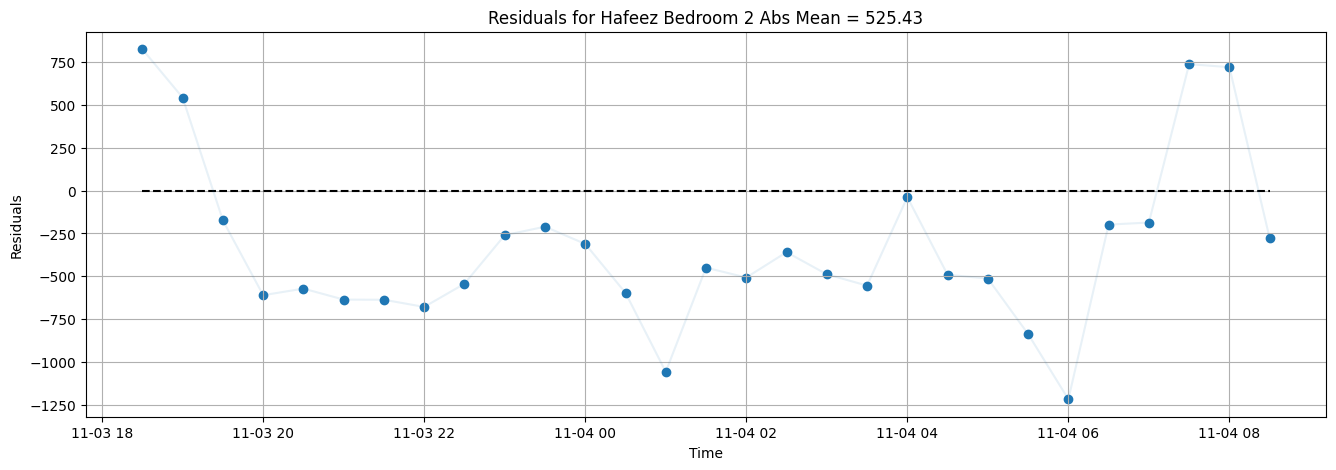

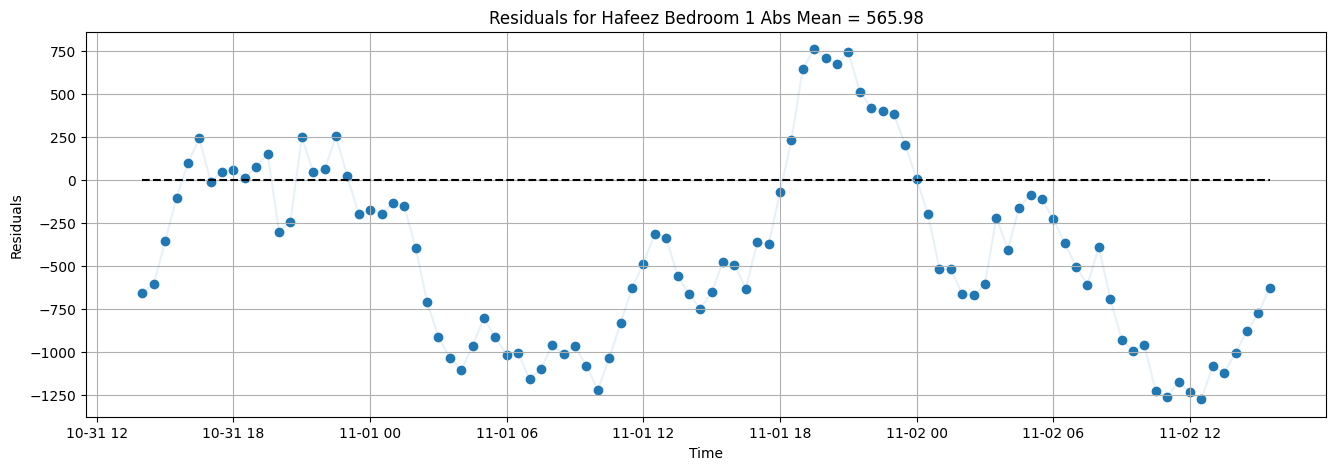

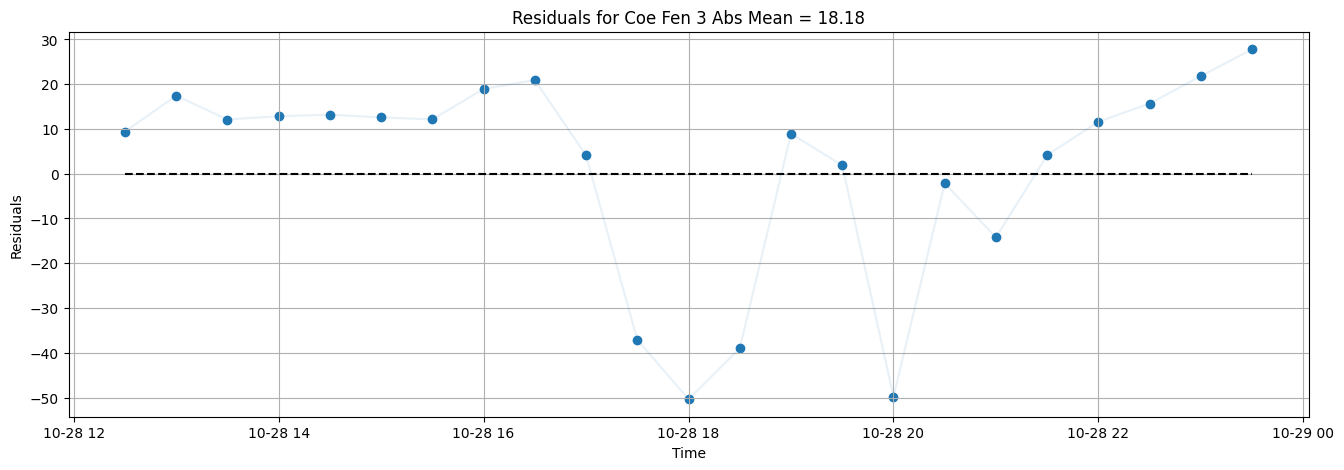

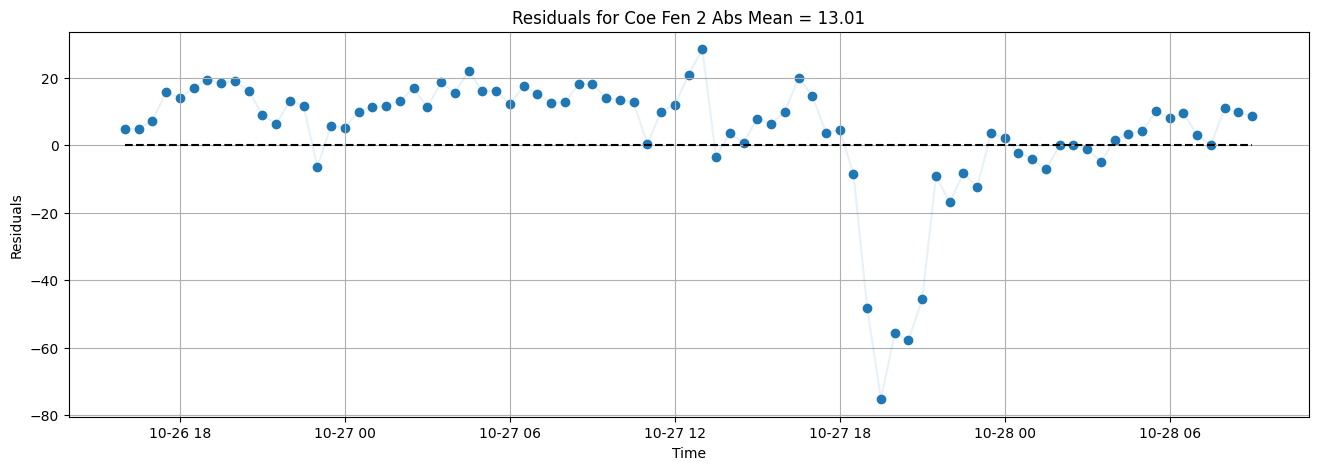

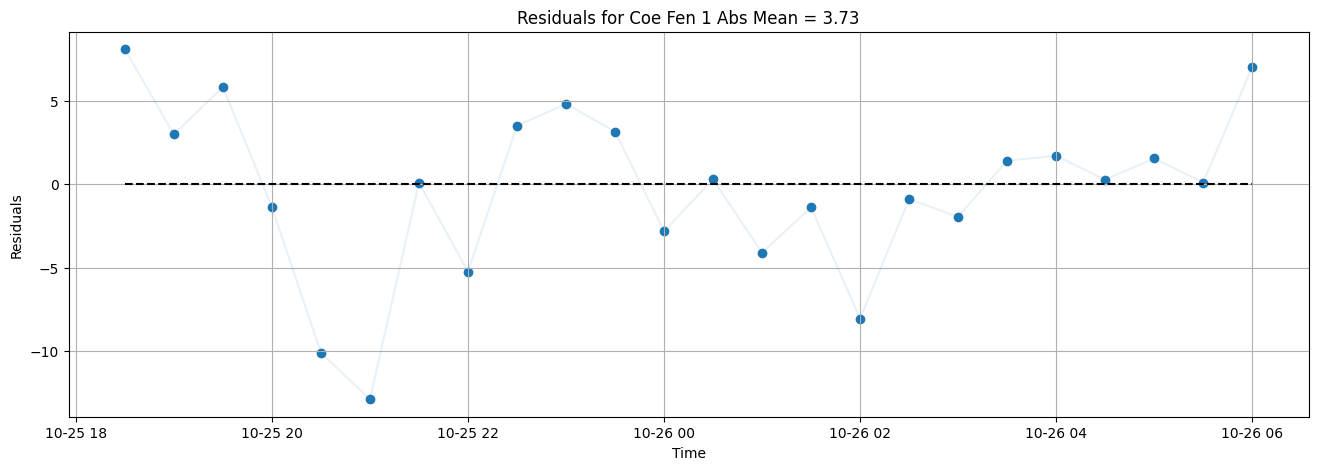

In [ ]:
# Residuals

### Grabbing all everythings
ind_pairs = np.zeros((len(end_indices),2))
results   = np.zeros((len(end_indices), 8))

locations = ['Coe Fen 1', 'Coe Fen 2', 'Coe Fen 3','Hafeez Bedroom 1', 'Hafeez Bedroom 2'
, 'Sidney Gardens', 'Botanic', 'Clare Hall 1', 'Clare Hall 2', 'Wolfson']

ind_pairs[:,0] = start_indices

for i in range(1, len(end_indices)): # This loop populates ind_pairs correctly
  ind_pairs[i,1] = end_indices[i-1]

# Model function. Linear regression returning A, B, C
def model(dataset, fsignal, gsignal, rural_mean_param):
  # Df merge
  merged_data = pd.merge(dataset, fsignal, on='Local Date/Time', how='inner')
  merged_data = pd.merge(merged_data, gsignal, on='Local Date/Time', how='inner')

  # Array pull
  co2_values = merged_data['CO2 (ppm) calib'].values
  f_values = merged_data['f_signal'].values
  g_values = merged_data['g_signal'].values

  f_values = f_values.values.flatten() if isinstance(f_values, pd.Series) else f_values.flatten()
  g_values = g_values.values.flatten() if isinstance(g_values, pd.Series) else g_values.flatten()

  X         = np.column_stack([f_values, g_values])
  beta, *_  = np.linalg.lstsq(X, co2_values - rural_mean_param, rcond=None)

  return beta, merged_data

### Builds Synth data based on model above. Compares
def synthetic_data(dataset, fsignal, gsignal, rural_mean_param, graph):

  beta, merged_data = model(dataset, fsignal, gsignal, rural_mean_param)

  synth_time = merged_data['Local Date/Time']
  true_CO2   = merged_data['CO2 (ppm) calib']

  f_values_for_synth = merged_data['f_signal'].values
  g_values_for_synth = merged_data['g_signal'].values

  synth_CO2  = rural_mean_param + beta[0]*f_values_for_synth + beta[1]*g_values_for_synth

  residuals  = synth_CO2 - true_CO2

  r2 = r2_score(true_CO2, synth_CO2)


  # Place holder
  if graph == 1:
    print('There shall be graphs')

    fig, axs = plt.subplots(3, 1, figsize=(16, 20))
    ax0, ax1, ax2 = axs

    # CO2 Comparison
    ax0.scatter(synth_time, true_CO2, label = 'Original Data')
    ax0.plot(synth_time, synth_CO2, label = 'Synthetic Data')


    ax0.grid()
    ax0.set_ylabel('CO2 (ppm)', fontdict = font16)
    ax0.set_xlabel('Time', fontdict = font16)
    ax0.set_title(f'CO2 Calib, A = {np.round(rural_mean_param,2)}, B = {np.round(beta[0],2)}, C = {np.round(beta[1],2)}, r^2 = {np.round(r2,3)}', fontdict = font20)
    ax0.legend()

    # f(t) and g(t)
    ax1.plot(synth_time, merged_data['f_signal'], label = 'f(t)')
    ax1.plot(synth_time, merged_data['g_signal'], label = 'g(t)')
    ax1.hlines(0, synth_time.min(), synth_time.max(), linestyles='dashed', colors='black')
    ax1.grid()
    ax1.set_ylabel('f(t) and g(t)', fontdict = font16)
    ax1.set_xlabel('Time', fontdict = font16)
    ax1.set_title('f(t) and g(t)', fontdict = font20)
    ax1.legend()


    # Residual versus time
    ax2.plot(synth_time, synth_CO2 - true_CO2)
    ax2.hlines(0, synth_time.min(), synth_time.max(), linestyles='dashed', colors='black')


    ax2.grid()
    ax2.set_ylabel('d', fontdict = font16)
    ax2.set_xlabel('Time', fontdict = font16)
    ax2.set_title(f'Residual vs. Time, Abs Mean = {np.round(np.mean(np.abs(residuals)),2)}, dw = {np.round(durbin_watson(residuals),2)}',  fontdict = font20)

  return synth_CO2, residuals, r2

# Definition of everything_pt2 (moved here to resolve NameError)
def everything_pt2(start_ind, end_ind, bin_minutes ,data_clean, data_chem, data_rural, graph):
  window_data, window_chem, window_rural = data_window(data_trim, data_clean, data_chem, data_rural, start_ind, end_ind, graph)

  window_bins       = binner(window_data,  bin_minutes, graph, align_bins=True)
  window_chem_bins  = binner(window_chem,  bin_minutes, graph, align_bins=True )
  window_rural_bins = binner(window_rural, bin_minutes, graph, align_bins=True )

  signal_time, fsignal, gsignal, rural_mean = signal_extraction(window_chem, window_rural, bin_minutes, graph)

  beta, merged_data = model(window_bins, fsignal, gsignal, rural_mean)

  normbeta, normmerged_data = model(window_chem_bins, fsignal, gsignal, rural_mean)

  synth_CO2, residuals, r2 = synthetic_data(window_bins, fsignal, gsignal, rural_mean, graph)

  print('RUN SUMMARY')
  print(beta)
  print(np.mean(residuals))

  return window_data, window_chem, window_rural, rural_mean, beta, normbeta, merged_data, residuals, r2


for j in range(len(end_indices)): # This loop iterates through the ind_pairs
  # Use ind_pairs[j,0] and ind_pairs[j,1] for the current iteration
  _window_data, _window_chem, _window_rural, _rural_mean, _beta, _norm_beta, _merged_data, _residuals, _r2 = everything_pt2(int(ind_pairs[j,0]), int(ind_pairs[j,1]), 30, data_clean, data_chem, data_rural, 0)

  fig, axs = plt.subplots(1, 1, figsize=(16, 5))
  ax0 = axs

  ax0.hlines(0, _merged_data['Local Date/Time'].min(), _merged_data['Local Date/Time'].max(), linestyles='dashed', colors='black')
  ax0.set_xlabel('Time')
  ax0.set_ylabel('Residuals')
  ax0.set_title(f'Residuals for {locations[len(locations) -1 -j]} Abs Mean = {np.round(np.mean(np.abs(_residuals)),2)}')

  ax0.scatter(_merged_data['Local Date/Time'], _residuals)
  ax0.plot(_merged_data['Local Date/Time'], _residuals, alpha = 0.1)

  ax0.grid()

# Linear Regression and Fitting

In [ ]:
### Model function. Linear regression returning A, B, C
signal_time, fsignal, gsignal, rural_mean = signal_extraction(Sidney_chem, Sidney_rural, 30, 0)


# Linear Regression
def model(dataset, fsignal, gsignal):
  # Df merge
  merged_data = pd.merge(dataset, fsignal, on='Local Date/Time', how='inner')
  merged_data = pd.merge(merged_data, gsignal, on='Local Date/Time', how='inner')

  # Array pull
  co2_values = merged_data['CO2 (ppm) calib'].values
  f_values = merged_data['f_signal'].values
  g_values = merged_data['g_signal'].values

  f_values = f_values.values.flatten() if isinstance(f_values, pd.Series) else f_values.flatten()
  g_values = g_values.values.flatten() if isinstance(g_values, pd.Series) else g_values.flatten()

  X         = np.column_stack([f_values, g_values])
  beta, *_  = np.linalg.lstsq(X, co2_values - rural_mean, rcond=None)


  return beta, merged_data


In [ ]:
### Builds Synth data based on model above. Compares
signal_time, fsignal, gsignal, rural_mean = signal_extraction(Sidney_chem, Sidney_rural, 30, 0)

def synthetic_data(dataset, fsignal, gsignal, graph):

  beta, merged_data = model(dataset, fsignal, gsignal)

  synth_time = merged_data['Local Date/Time']
  true_CO2   = merged_data['CO2 (ppm) calib']

  f_values_for_synth = merged_data['f_signal'].values
  g_values_for_synth = merged_data['g_signal'].values

  synth_CO2  = rural_mean + beta[0]*f_values_for_synth + beta[1]*g_values_for_synth

  residuals  = synth_CO2 - true_CO2

  r2 = r2_score(true_CO2, synth_CO2)


  # Place holder
  if graph == 1:
    print('There shall be graphs')

    fig, axs = plt.subplots(3, 1, figsize=(16, 20))
    ax0, ax1, ax2 = axs

    # CO2 Comparison
    ax0.scatter(synth_time, true_CO2, label = 'Original Data')
    ax0.plot(synth_time, synth_CO2, label = 'Synthetic Data')


    ax0.grid()
    ax0.set_ylabel('CO2 (ppm)', fontdict = font16)
    ax0.set_xlabel('Time', fontdict = font16)
    ax0.set_title(f'CO2 Calib, A = {np.round(rural_mean,2)}, B = {np.round(beta[0],2)}, C = {np.round(beta[1],2)}, r^2 = {np.round(r2,3)}', fontdict = font20)
    ax0.legend()

    # f(t) and g(t)
    ax1.plot(synth_time, merged_data['f_signal'], label = 'f(t)')
    ax1.plot(synth_time, merged_data['g_signal'], label = 'g(t)')
    ax1.hlines(0, synth_time.min(), synth_time.max(), linestyles='dashed', colors='black')
    ax1.grid()
    ax1.set_ylabel('f(t) and g(t)', fontdict = font16)
    ax1.set_xlabel('Time', fontdict = font16)
    ax1.set_title('f(t) and g(t)', fontdict = font20)
    ax1.legend()


    # Residual versus time
    ax2.plot(synth_time, synth_CO2 - true_CO2)
    ax2.hlines(0, synth_time.min(), synth_time.max(), linestyles='dashed', colors='black')


    ax2.grid()
    ax2.set_ylabel('d', fontdict = font16)
    ax2.set_xlabel('Time', fontdict = font16)
    ax2.set_title(f'Residual vs. Time, Abs Mean = {np.round(np.mean(np.abs(residuals)),2)}, dw = {np.round(durbin_watson(residuals),2)}',  fontdict = font20)

  #else:
  #  print('No graphs')

  return synth_CO2, residuals, r2



# Stats testing


In [ ]:
# To be developed

# The Everything Functions

In [ ]:
### Pt 1
# Does everything in two stages
# Takes: threshold, blast_radius, data_trim

# Returns: Data fit and stats analysis

def everything_pt1(threshold, blast_radius, data_trim):
  data_clean = cleaning(threshold, blast_radius, data_trim)
  index_finder(data_trim, data_clean)



              # seconds, datapoints
everything_pt1(-3600, 30, data_trim)


end indicies [ 2322  3536  5670  5842  8723  9372 11522 12214 14612 15345]
start indicies [ 2321  3535  5669  5841  8722  9371 11521 12213 14611 15344]

Start Times
2321    2025-11-22 20:22:04
3535    2025-11-17 16:16:50
5669    2025-11-15 16:37:36
5841    2025-11-09 10:40:30
8722    2025-11-05 11:48:38
9371    2025-11-03 18:12:37
11521   2025-10-31 13:52:32
12213   2025-10-28 11:53:43
14611   2025-10-26 15:31:01
15344   2025-10-25 18:23:00
Name: Local Date/Time, dtype: datetime64[ns]


In [ ]:
data_trim['TVOC (ppb)'].mean()

np.float64(112.32829719679603)

In [ ]:
### Pt 2
# Takes: start_ind, end_ind, bin_minutes, data_clean, data_chem, data_rural, graph

def everything_pt2(start_ind, end_ind, bin_minutes ,data_clean, data_chem, data_rural, graph):
  window_data, window_chem, window_rural = data_window(data_trim, data_clean, data_chem, data_rural, start_ind, end_ind, graph)

  window_bins       = binner(window_data,  bin_minutes, graph, align_bins=True)
  window_chem_bins  = binner(window_chem,  bin_minutes, graph, align_bins=True )
  window_rural_bins = binner(window_rural, bin_minutes, graph, align_bins=True )

  signal_time, fsignal, gsignal, rural_mean = signal_extraction(window_chem, window_rural, bin_minutes, graph)

  beta, merged_data = model(window_bins, fsignal, gsignal)

  normbeta, normmerged_data = model(window_chem_bins, fsignal, gsignal)

  synth_CO2, residuals, r2 = synthetic_data(window_bins, fsignal, gsignal, graph)

  print('RUN SUMMARY')
  print(beta)
  print(np.mean(residuals))

  return window_data, window_chem, window_rural, rural_mean, beta, normbeta, merged_data, residuals, r2

In [ ]:
### Grabbing all everythings
# ind_pairs = np.zeros((len(end_indices), 2))
# ind_pairs[:,0] = start_indices
# for i in range(1, len(end_indices)): # This loop populates ind_pairs correctly
#   ind_pairs[i,1] = end_indices[i-1]

results   = np.zeros((11, 9))


ind_pairs = np.array([[ 2321.,     0.],
       [ 3535.,  2322.],
       [ 5669.,  3536.],
       [ 5842.,  5670.],
       [ 7236.,  5842.],
       [ 8722.,  7242.],
       [ 9371.,  8723.],
       [11521.,  9372.],
       [12213., 11522.],
       [14611., 12214.],
       [15344., 14612.]])


for j in range(11): # This loop iterates through the ind_pairs
  # Use ind_pairs[j,0] and ind_pairs[j,1] for the current iteration
  _window_data, _window_chem, _window_rural, _rural_mean, _beta, _norm_beta, _merged_data, _residuals, _r2 = everything_pt2(int(ind_pairs[j,0]), int(ind_pairs[j,1]), 30, data_clean, data_chem, data_rural, 0)

  # Get the actual min and max times from the filtered window_data and convert to Unix timestamp
  results[j,0]   = np.round((_window_data['Local Date/Time'].max().timestamp() - _window_data['Local Date/Time'].min().timestamp() )/ 3600, 2)
  results[j,0+1] = _window_data['Local Date/Time'].min().timestamp()
  results[j,1+1] = _window_data['Local Date/Time'].max().timestamp()
  results[j,2+1] = np.round(_rural_mean, 2)
  results[j,3+1] = np.round(_beta[0],2)
  results[j,4+1] = np.round(_beta[1],2)
  results[j,5+1] = np.round(np.mean(np.abs(_residuals)),2)
  results[j,6+1] = np.round(_r2,3)
  results[j,7+1] = np.round(durbin_watson(_residuals),2)


RUN SUMMARY
[1.59708281 0.14403726]
3.891516039361099
RUN SUMMARY
[0.29891171 1.10992654]
-0.40173142386076677
RUN SUMMARY
[1.5541567 1.0404044]
-0.25656058556014744
RUN SUMMARY
[0.0746013  0.73062829]
-0.32193419815403485
RUN SUMMARY
[1.23320846 1.0674818 ]
-1.2815818360769156
RUN SUMMARY
[2.25018672 1.30554939]
-0.8158456926373117
RUN SUMMARY
[-163.79202534  409.60396263]
-327.2800197562123
RUN SUMMARY
[ 26.38427904 102.78025033]
-421.1125944849365
RUN SUMMARY
[6.10919531 4.01746132]
2.2082712711362693
RUN SUMMARY
[0.56672903 1.21072107]
6.887710965158691
RUN SUMMARY
[-3.05106684 -0.8126222 ]
-0.015932809129701297


In [ ]:
results = pd.DataFrame(results, columns = ['Duration','Start Time', 'End Time','A = RMean', 'B', 'C', 'average d', 'R^2', 'Durbin Watson'])
results['Start Time'] = pd.to_datetime(results['Start Time'], unit='s')
results['End Time'] = pd.to_datetime(results['End Time'], unit='s')
results

,Duration,Start Time,End Time,A = RMean,B,C,average d,R^2,Durbin Watson
0,38.66,2025-11-22 20:55:56,2025-11-24 11:35:33,433.80,1.60,0.14,8.14,0.012,0.85
1,19.20,2025-11-17 16:47:00,2025-11-18 11:59:12,434.11,0.30,1.11,6.95,0.323,0.92
2,34.54,2025-11-15 17:07:47,2025-11-17 03:40:13,432.79,1.55,1.04,2.25,0.718,1.03
3,1.83,2025-11-09 11:10:46,2025-11-09 13:00:50,435.76,0.07,0.73,1.49,0.327,1.58
4,23.61,2025-11-06 13:34:47,2025-11-07 13:11:28,437.36,1.23,1.07,7.68,0.373,1.14
5,25.11,2025-11-05 12:20:00,2025-11-06 13:26:29,436.90,2.25,1.31,5.78,0.605,1.98
6,13.67,2025-11-03 18:46:05,2025-11-04 08:26:07,431.00,-163.79,409.60,522.09,-0.653,0.52
7,48.82,2025-10-31 14:25:23,2025-11-02 15:14:43,431.21,26.38,102.78,563.22,-1.167,0.07
8,10.89,2025-10-28 12:26:11,2025-10-28 23:19:45,430.74,6.11,4.02,18.71,0.293,0.80
9,40.55,2025-10-26 16:02:02,2025-10-28 08:34:45,429.49,0.57,1.21,15.78,0.030,0.19


RUN SUMMARY
[1.59708281 0.14403726]
3.891516039361099
RUN SUMMARY
[0.29891171 1.10992654]
-0.40173142386076677
RUN SUMMARY
[1.5541567 1.0404044]
-0.25656058556014744
RUN SUMMARY
[0.31123545 0.6931508 ]
-0.37103686140797737
RUN SUMMARY
[1.53180089 1.17197547]
-2.7758554405299196
RUN SUMMARY
[-163.79202534  409.60396263]
-327.2800197562123
RUN SUMMARY
[ 26.38427904 102.78025033]
-421.1125944849365
RUN SUMMARY
[6.10919531 4.01746132]
2.2082712711362693
RUN SUMMARY
[0.56672903 1.21072107]
6.887710965158691
RUN SUMMARY
[-3.05106684 -0.8126222 ]
-0.015932809129701297


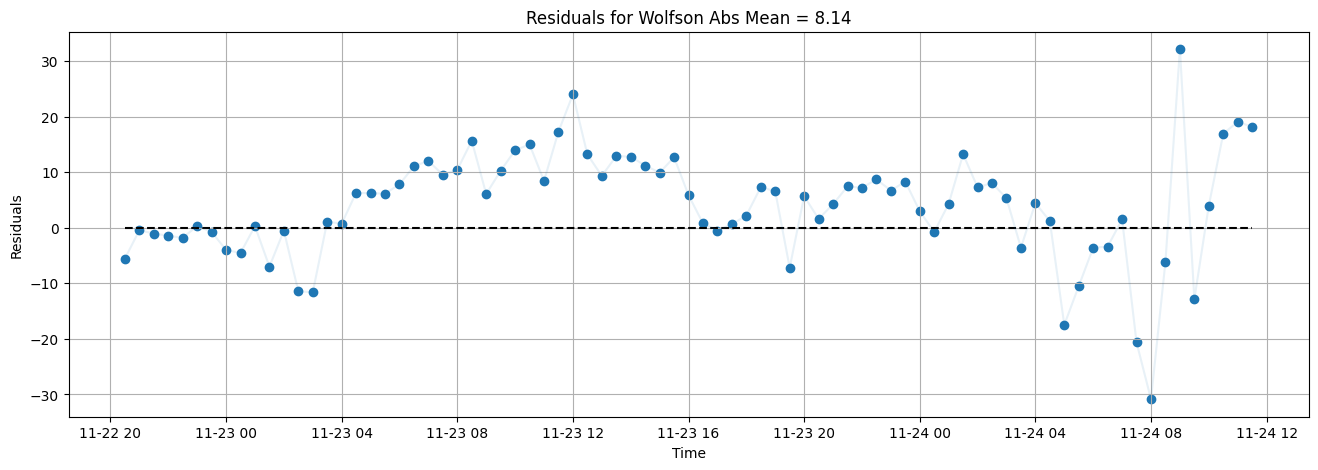

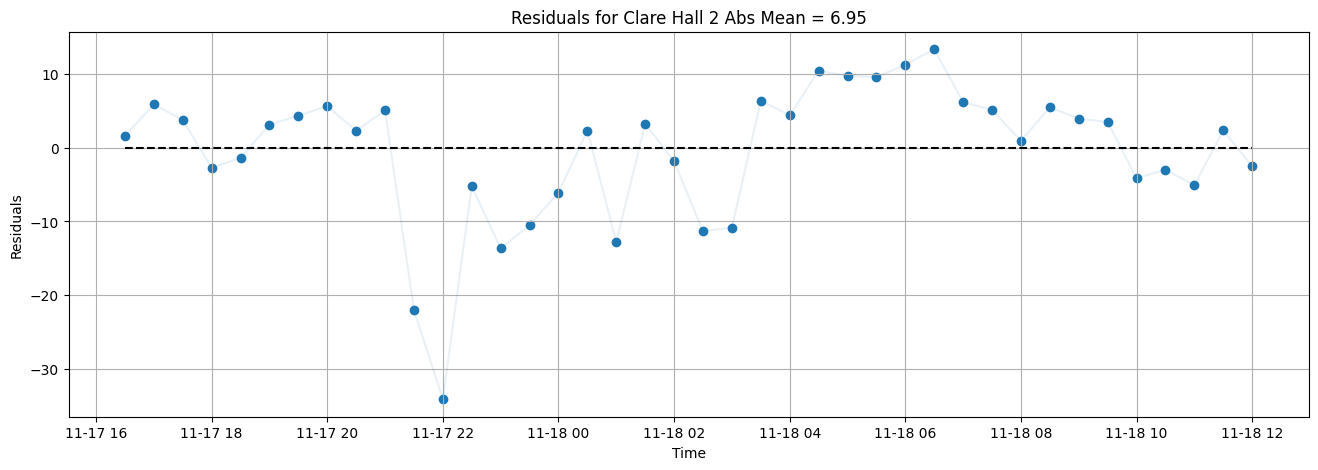

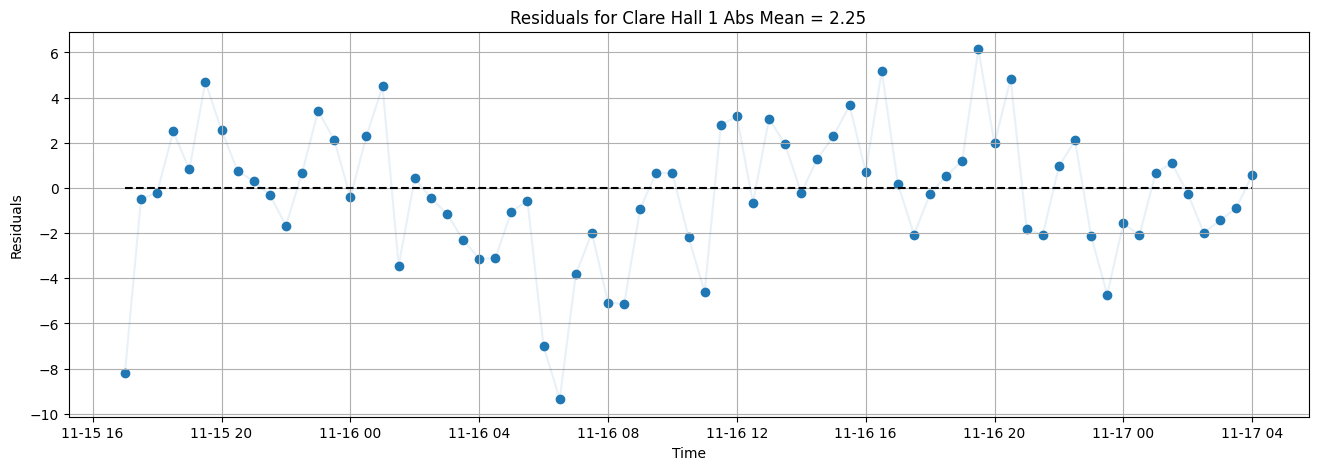

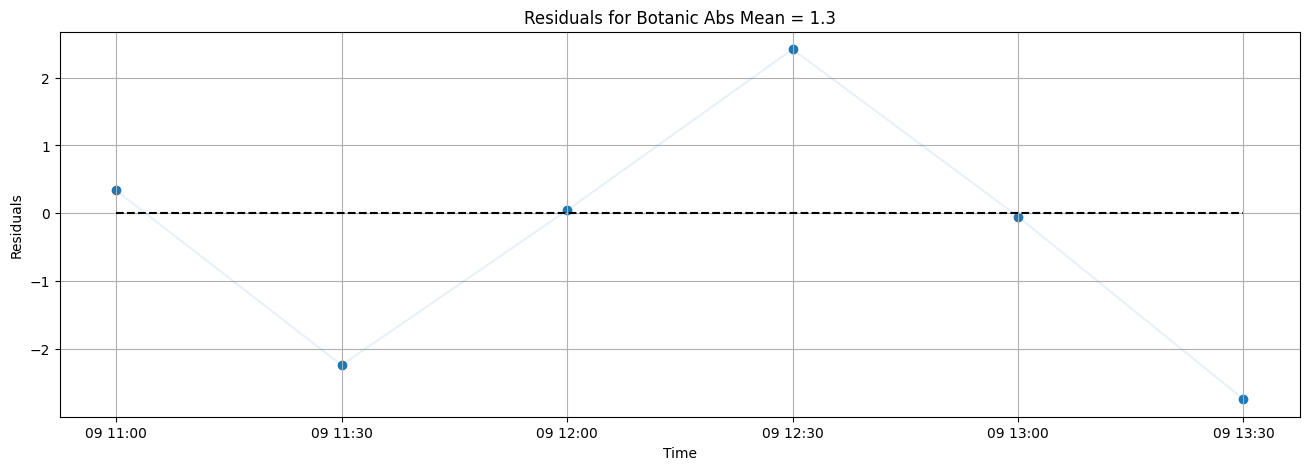

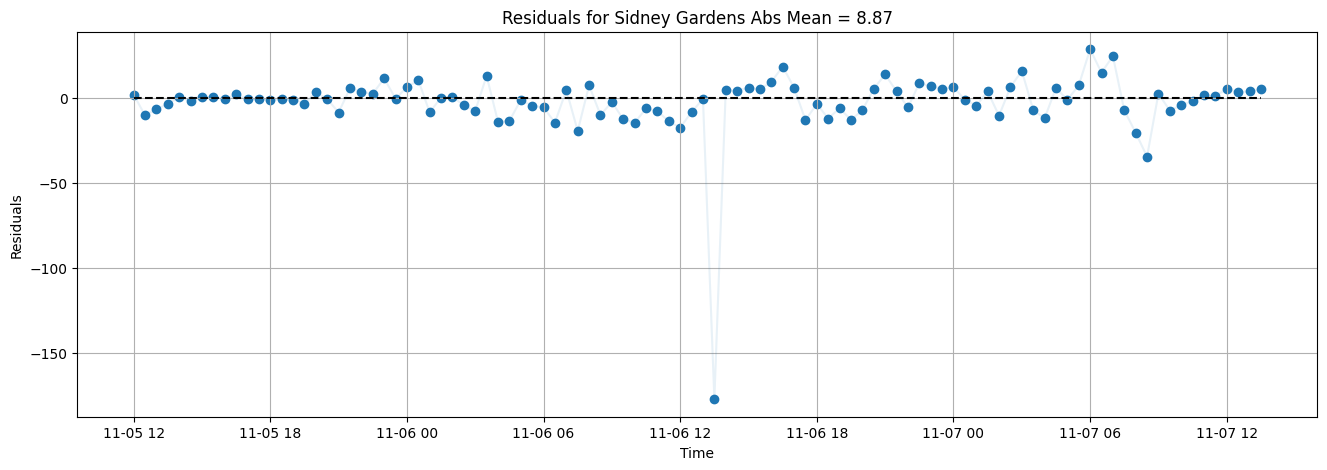

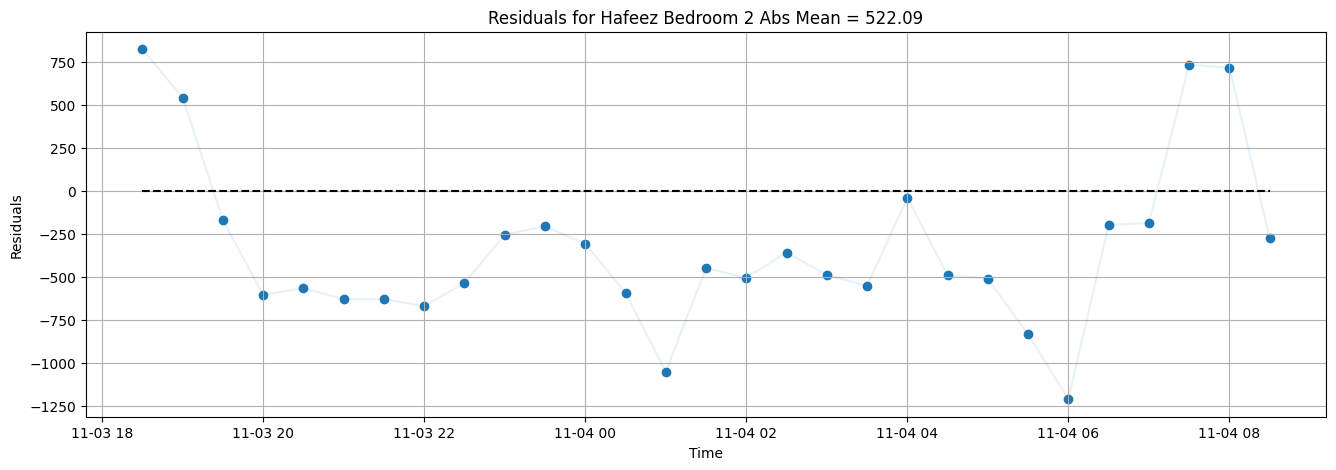

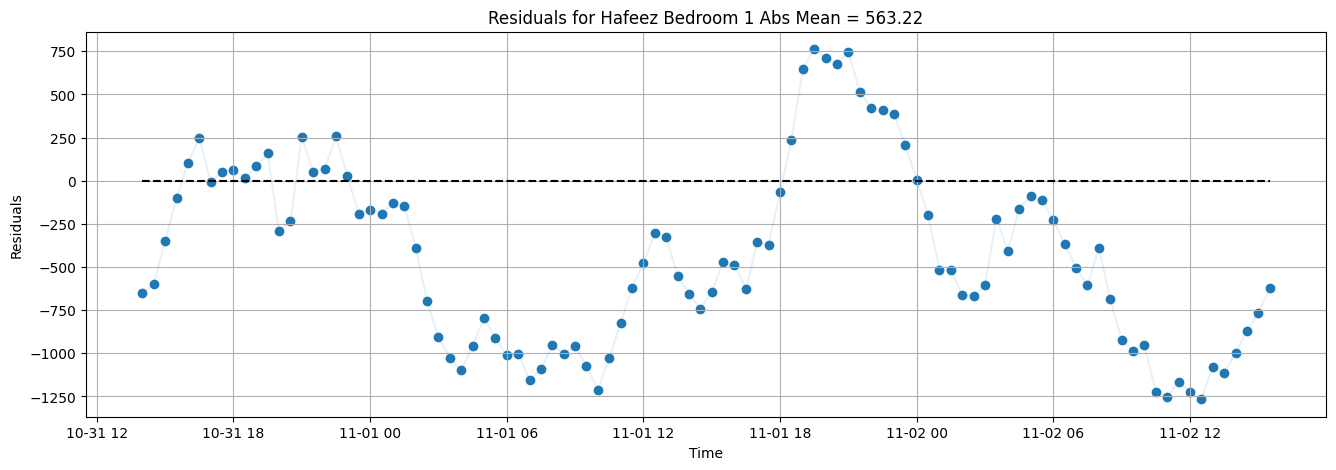

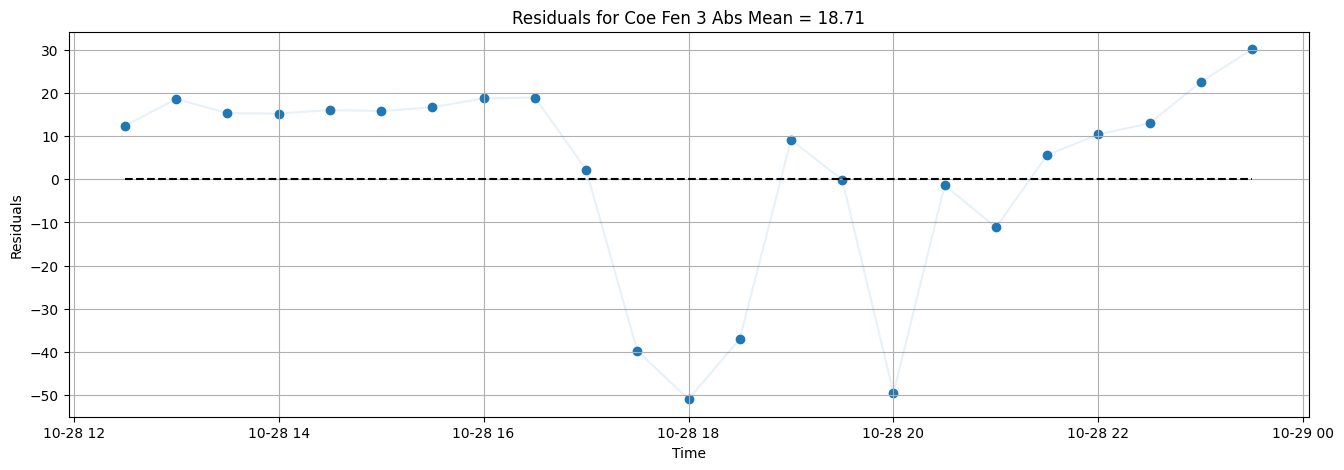

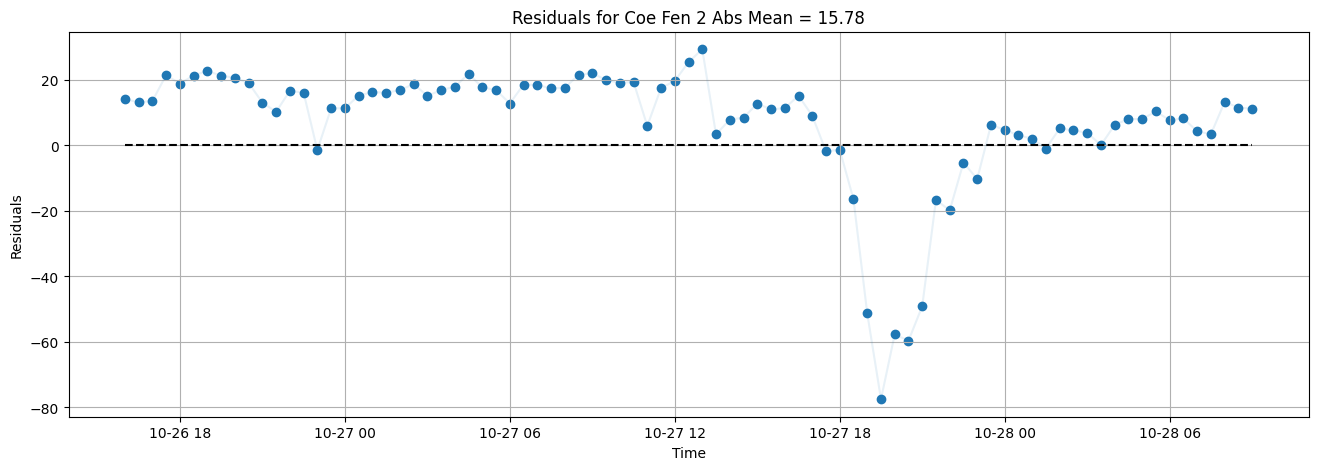

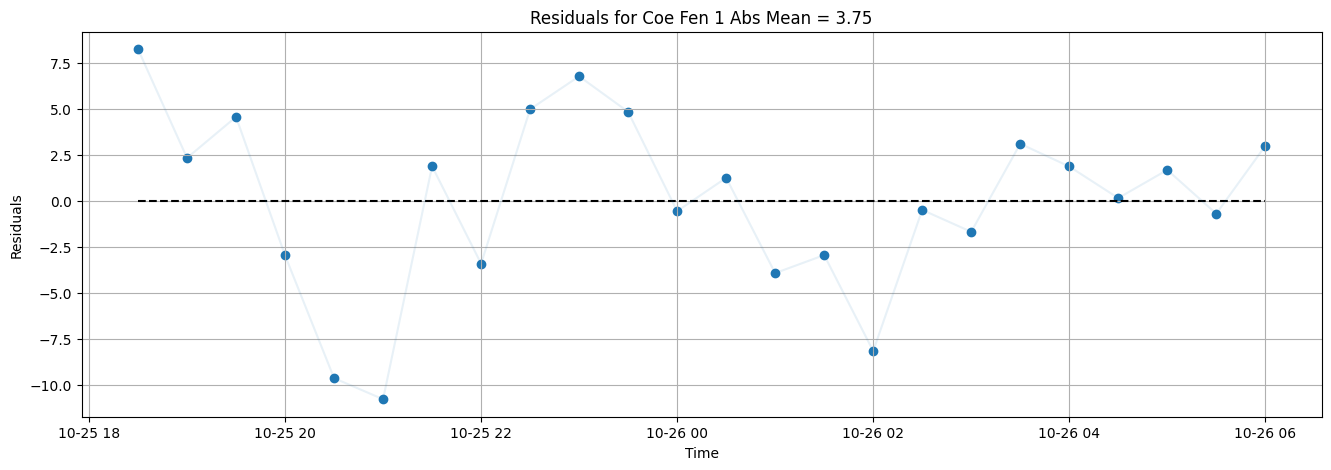

In [ ]:
# Residuals

### Grabbing all everythings
ind_pairs = np.zeros((len(end_indices),2))
results   = np.zeros((len(end_indices), 8))

locations = ['Coe Fen 1', 'Coe Fen 2', 'Coe Fen 3','Hafeez Bedroom 1', 'Hafeez Bedroom 2'
, 'Sidney Gardens', 'Botanic', 'Clare Hall 1', 'Clare Hall 2', 'Wolfson']

ind_pairs[:,0] = start_indices

for i in range(1, len(end_indices)): # This loop populates ind_pairs correctly
  ind_pairs[i,1] = end_indices[i-1]

for j in range(len(end_indices)): # This loop iterates through the ind_pairs
  # Use ind_pairs[j,0] and ind_pairs[j,1] for the current iteration
  _window_data, _window_chem, _window_rural, _rural_mean, _beta, _norm_beta, _merged_data, _residuals, _r2 = everything_pt2(int(ind_pairs[j,0]), int(ind_pairs[j,1]), 30, data_clean, data_chem, data_rural, 0)

  fig, axs = plt.subplots(1, 1, figsize=(16, 5))
  ax0 = axs

  ax0.hlines(0, _merged_data['Local Date/Time'].min(), _merged_data['Local Date/Time'].max(), linestyles='dashed', colors='black')
  ax0.set_xlabel('Time')
  ax0.set_ylabel('Residuals')
  ax0.set_title(f'Residuals for {locations[len(locations) -1 -j]} Abs Mean = {np.round(np.mean(np.abs(_residuals)),2)}')

  ax0.scatter(_merged_data['Local Date/Time'], _residuals)
  ax0.plot(_merged_data['Local Date/Time'], _residuals, alpha = 0.1)

  ax0.grid()

 # Fast Fourier

Chem  47.97916666666667
Rural  32.020833333333336


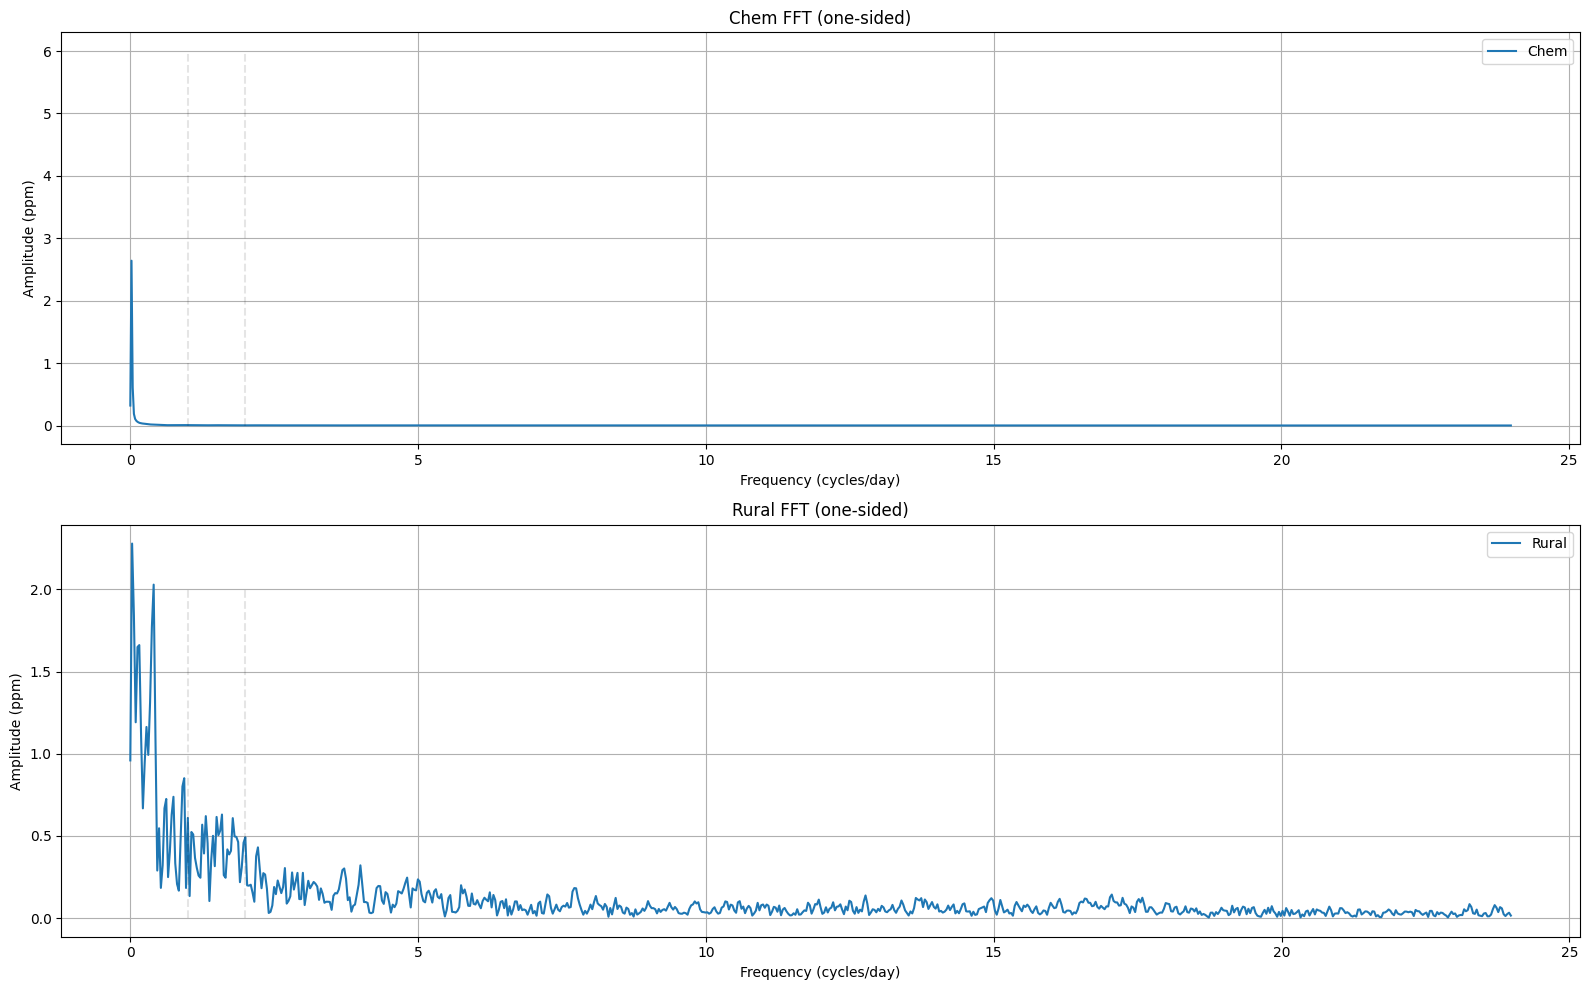

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq   # one-sided for real signals
from scipy.signal import get_window


full_chem  = binner(data_chem,  30, 0, align_bins=True)   # 30-minute bins?
full_rural = binner(data_rural, 30, 0, align_bins=True)

Nchem  = full_chem.shape[0]
Nrural = full_rural.shape[0]

# sample spacing (seconds) if bins are 30 minutes
T = 30 * 60.0                # 1800 s
fs = 1.0 / T                 # Hz

# --- extract series and handle NaNs ---
s_chem  = full_chem['CO2 (ppm) calib'].to_numpy()
s_rural = full_rural['CO2 (ppm) calib'].to_numpy()

# if there are NaNs from binning, fill or interpolate
# simplest: forward/back fill then mean-fill any edges
def fill_nans(x):
    x = x.astype(float)
    nans = ~np.isfinite(x)
    if nans.any():
        # linear interpolate over finite indices
        idx = np.arange(x.size)
        x[nans] = np.interp(idx[nans], idx[~nans], x[~nans])
    return x

s_chem  = fill_nans(s_chem)
s_rural = fill_nans(s_rural)

# --- detrend: remove mean (DC) ---
s_chem  = s_chem  - np.mean(s_chem)
s_rural = s_rural - np.mean(s_rural)

# --- optional: window to reduce leakage ---
w_chem  = get_window('hann', Nchem)
w_rural = get_window('hann', Nrural)

s_chem_w  = s_chem  * w_chem
s_rural_w = s_rural * w_rural

# coherent gain of Hann window for amplitude correction
# (sum(w)/N); using amplitude-preserving factor below
cg_chem  = np.sum(w_chem)  / Nchem
cg_rural = np.sum(w_rural) / Nrural

# --- FFT (one-sided) ---
Y_chem  = rfft(s_chem_w)
Y_rural = rfft(s_rural_w)

f_chem  = rfftfreq(Nchem, d=T)   # Hz
f_rural = rfftfreq(Nrural, d=T)  # Hz

# --- magnitude & phase ---
# Scale to preserve sinusoid amplitudes (account for one-sided & window gain)
# 2/N for one-sided, except DC and Nyquist bins
def one_sided_amp(Y, N, cg):
    A = np.abs(Y) / (N * cg)   # remove window gain and N
    A[1:-1] *= 2.0             # double non-DC, non-Nyquist bins
    return A

mag_chem  = one_sided_amp(Y_chem,  Nchem,  cg_chem)
mag_rural = one_sided_amp(Y_rural, Nrural, cg_rural)

phase_chem  = np.angle(Y_chem)
phase_rural = np.angle(Y_rural)

# --- optional: convert Hz -> cycles/day for readability ---
sec_per_day = 86400.0
f_chem_cpd  = f_chem  * sec_per_day
f_rural_cpd = f_rural * sec_per_day

# --- plot ---
fig, axs = plt.subplots(2, 1, figsize=(16, 10), sharex=False)
ax0, ax1 = axs

ax0.plot(f_chem_cpd,  mag_chem,  label='Chem')
ax1.plot(f_rural_cpd, mag_rural, label='Rural')

ax0.vlines(1, 0,6, linestyles='dashed', colors='black', alpha =0.1)
ax0.vlines(2, 0,6, linestyles='dashed', colors='black', alpha =0.1)


ax1.vlines(1, 0,2, linestyles='dashed', colors='black', alpha =0.1)
ax1.vlines(2, 0,2, linestyles='dashed', colors='black', alpha =0.1)


for ax, title in zip(axs, ['Chem FFT (one-sided)', 'Rural FFT (one-sided)']):
    ax.grid(True)
    ax.set_xlabel('Frequency (cycles/day)')
    ax.set_ylabel('Amplitude (ppm)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()


print('Chem ', 1/ f_chem_cpd[np.argmax(mag_chem)])
print('Rural ', 1/ f_rural_cpd[np.argmax(mag_rural)])



# Collated residuals

RUN SUMMARY
[1.59708281 0.14403726]
3.891516039361099
RUN SUMMARY
[0.29891171 1.10992654]
-0.40173142386076677
RUN SUMMARY
[1.5541567 1.0404044]
-0.25656058556014744
RUN SUMMARY
[0.0746013  0.73062829]
-0.32193419815403485
RUN SUMMARY
[1.23320846 1.0674818 ]
-1.2815818360769156
RUN SUMMARY
[2.25018672 1.30554939]
-0.8158456926373117
RUN SUMMARY
[6.10919531 4.01746132]
2.2082712711362693
RUN SUMMARY
[0.56672903 1.21072107]
6.887710965158691
RUN SUMMARY
[-3.05106684 -0.8126222 ]
-0.015932809129701297


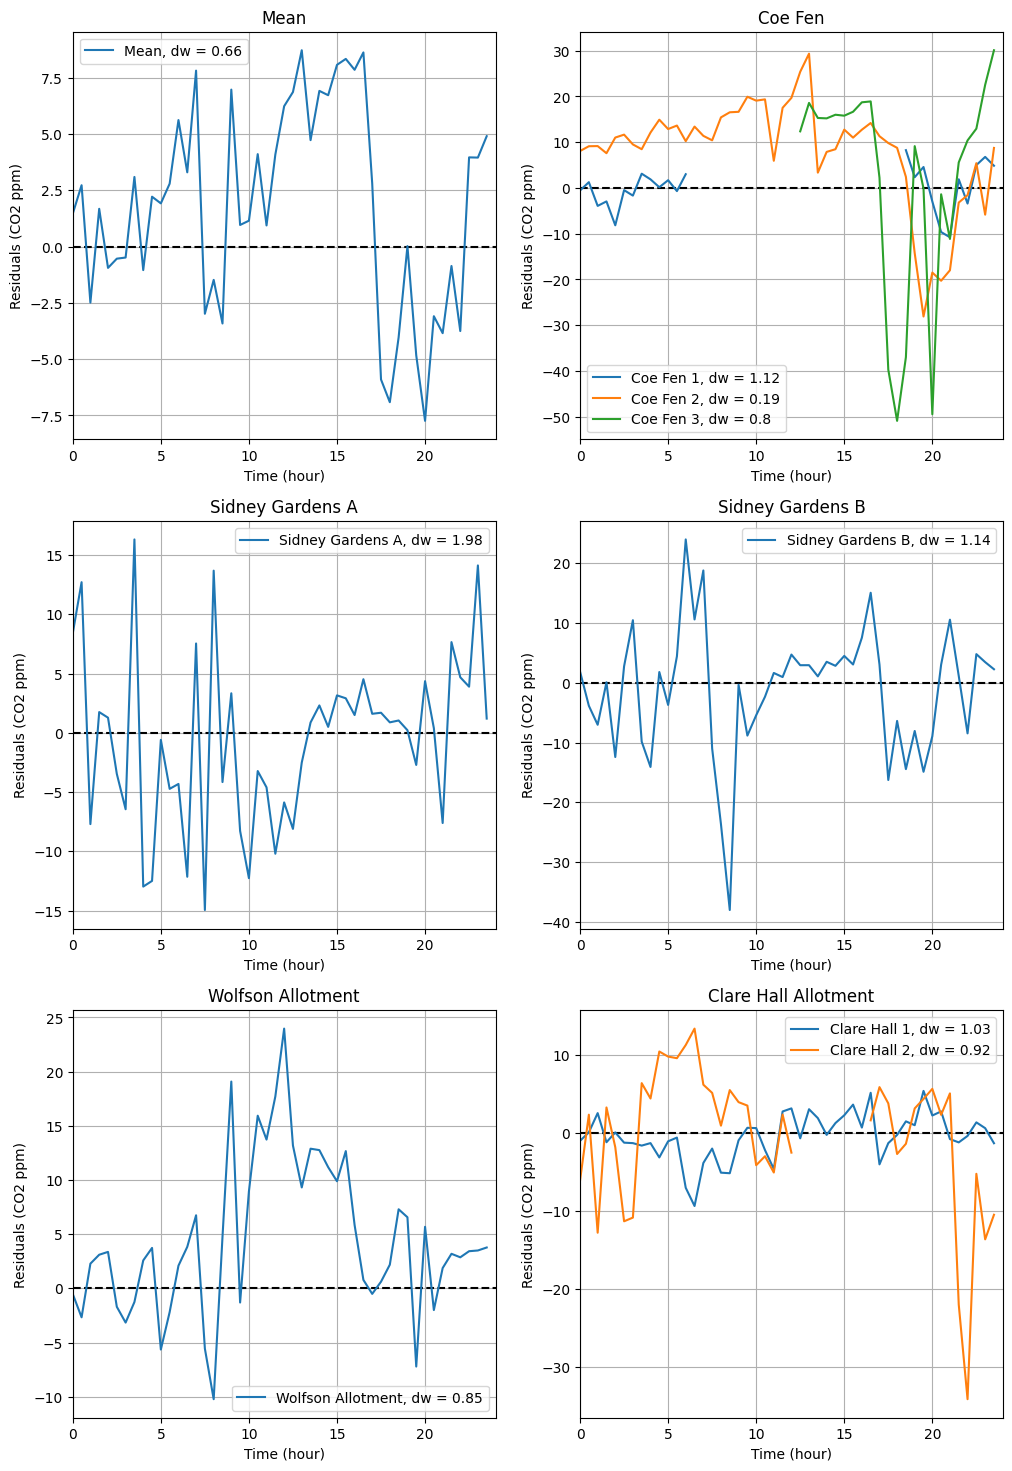

In [ ]:
### Idea here is to stack all data sets and show residuals

### DURBIN WATSON IS TAKEN SEPERATELY FROM THE ACTUAL SERIES NOT THE SYNTHETIC PLOTS

# Locs
locations = ['Wolfson Allotment', 'Clare Hall Allotment 2', 'Clare Hall Allotment 1'
              , 'Botanic Gardens', 'Sidney Gardens 2', 'Sidney Gardens 1'
              , 'Coe Fen 3', 'Coe Fen 2', 'Coe Fen 1']

desired_sets = np.array([0,1,2,3,4,5,8,9,10])

# Reconstruct merged_residuals to ensure all 'Residual_j' columns exist
# This part is moved from the previous cell (Bdh87BGXH5J_) for robustness
base_time_df = pd.DataFrame({
    'Time': pd.date_range('2000-01-01 00:00', '2000-01-01 23:30', freq='30min').time
})
merged_residuals = base_time_df.copy()

ind_pairs = np.array([[ 2321.,     0.],
       [ 3535.,  2322.],
       [ 5669.,  3536.],
       [ 5842.,  5670.],
       [ 7236.,  5842.],
       [ 8722.,  7242.],
       [ 9371.,  8723.],
       [11521.,  9372.],
       [12213., 11522.],
       [14611., 12214.],
       [15344., 14612.]])

dw_results = np.zeros(len(desired_sets))

for z, j in enumerate(desired_sets):
  _window_data, _window_chem, _window_rural, _rural_mean, _beta, _norm_beta, _merged_data, _residuals, _r2 = everything_pt2(int(ind_pairs[j,0]), int(ind_pairs[j,1]), 30, data_clean, data_chem, data_rural, 0)

  time_of_day       = _merged_data['Local Date/Time'].dt.time
  temp_residuals_df = pd.DataFrame({'Time': time_of_day, 'Residuals_Val': _residuals})
  averaged_residuals = temp_residuals_df.groupby('Time')['Residuals_Val'].mean().reset_index()

  merged_residuals = pd.merge(merged_residuals, averaged_residuals, on='Time', how='left', suffixes=('', f'_{j}'))
  merged_residuals = merged_residuals.rename(columns={'Residuals_Val': f'Residual_{j}'})

  dw_results[z] = durbin_watson(_residuals)
  #dw_results = pd.DataFrame(dw_results, columns = ['Durbin Watson'])
  #dw_results = dw_results.rename(columns={'Residuals_Val': f'Residual_{j}'})


for i in range(len(desired_sets)):
  merged_residuals[locations[i]] = merged_residuals[f'Residual_{desired_sets[i]}']
merged_residuals = merged_residuals.drop(columns=[f'Residual_{desired_sets[i]}' for i in range(len(desired_sets))])


# Forming Mean
mean_residuals = base_time_df.copy()
mean_residuals["Mean Residual"] = merged_residuals.mean(axis=1, skipna=True, numeric_only=True)


# Convert Time to a numerical format (seconds from midnight) for plotting
mean_residuals['Time_seconds'] = mean_residuals['Time'].apply(lambda t: t.hour * 3600 + t.minute * 60 + t.second)
merged_residuals['Time_seconds'] = merged_residuals['Time'].apply(lambda t: t.hour * 3600 + t.minute * 60 + t.second)


# Multiplot

fig, axs = plt.subplots(3, 2, figsize=(12, 18))
for ax_item in axs.flatten(): # Iterate over the flattened axes
  ax_item.set_xlabel('Time (hour)')
  ax_item.set_ylabel('Residuals (CO2 ppm)')
  ax_item.grid()
  ax_item.set_xlim(0,24)
  ax_item.hlines(0, 0, 24, linestyles='dashed', colors='black')

ax0, ax1, ax2, ax3, ax4, ax5 = axs.flatten()

# 6 Plots
# Mean, Coe Fen, Sidney A, Sidney B, Wolfson, Clare Hall


# Mean
dw_value = durbin_watson(mean_residuals['Mean Residual'])
ax0.plot(merged_residuals['Time_seconds']/3600, mean_residuals['Mean Residual'], label = f'Mean, dw = {np.round(dw_value,2)}')
ax0.set_title(f'Mean')
ax0.legend()

# Coe Fen
CoeFen1 = merged_residuals['Coe Fen 1']
CoeFen2 = merged_residuals['Coe Fen 2']
CoeFen3 = merged_residuals['Coe Fen 3']
dw_value1 = dw_results[8]
dw_value2 = dw_results[7]
dw_value3 = dw_results[6]
ax1.plot(merged_residuals['Time_seconds']/3600, CoeFen1, label = f'Coe Fen 1, dw = {np.round(dw_value1,2)}')
ax1.plot(merged_residuals['Time_seconds']/3600, CoeFen2, label = f'Coe Fen 2, dw = {np.round(dw_value2,2)}')
ax1.plot(merged_residuals['Time_seconds']/3600, CoeFen3, label = f'Coe Fen 3, dw = {np.round(dw_value3,2)}')
ax1.set_title('Coe Fen')
ax1.legend()


# Sidney A
dw_value = dw_results[5]
ax2.plot(merged_residuals['Time_seconds']/3600, merged_residuals['Sidney Gardens 1'], label = f'Sidney Gardens A, dw = {np.round(dw_value,2)}')
ax2.set_title(f'Sidney Gardens A')
ax2.legend()


# Sidney B
dw_value = dw_results[4]
ax3.plot(merged_residuals['Time_seconds']/3600, merged_residuals['Sidney Gardens 2'], label = f'Sidney Gardens B, dw = {np.round(dw_value,2)}')
ax3.set_title(f'Sidney Gardens B')
ax3.legend()


# Wolfson
dw_value = dw_results[0]
ax4.plot(merged_residuals['Time_seconds']/3600, merged_residuals['Wolfson Allotment'], label = f'Wolfson Allotment, dw = {np.round(dw_value,2)}')
ax4.set_title(f'Wolfson Allotment')
ax4.legend()


# Clare Hall
ClareHall1 = merged_residuals['Clare Hall Allotment 1']
ClareHall2 = merged_residuals['Clare Hall Allotment 2']
dw_value1 = dw_results[2]
dw_value2 = dw_results[1]
ax5.plot(merged_residuals['Time_seconds']/3600, ClareHall1, label = f'Clare Hall 1, dw = {np.round(dw_value1,2)}')
ax5.plot(merged_residuals['Time_seconds']/3600, ClareHall2, label = f'Clare Hall 2, dw = {np.round(dw_value2,2)}')
ax5.set_title('Clare Hall Allotment')
ax5.legend()



In [ ]:
dw_results

array([0.85219567, 0.92412352, 1.03464789, 1.57638602, 1.1376392 ,
       1.98337322, 0.80206266, 0.18722299, 1.11511185])

In [ ]:
merged_residuals

,Time,Wolfson Allotment,Clare Hall Allotment 2,Clare Hall Allotment 1,Botanic Gardens,Sidney Gardens 2,Sidney Gardens 1,Coe Fen 3,Coe Fen 2,Coe Fen 1,Time_seconds
0,00:00:00,-0.528996,-6.071773,-0.990305,NaN,1.875641,8.409560,NaN,8.074191,-0.552080,0
1,00:30:00,-2.674369,2.366096,0.101446,NaN,-3.842886,12.714603,NaN,9.121504,1.264291,1800
2,01:00:00,2.276829,-12.787489,2.568988,NaN,-7.019971,-7.705256,NaN,9.156494,-3.923838,3600
3,01:30:00,3.101238,3.293629,-1.170540,NaN,0.088113,1.750905,NaN,7.596154,-2.943136,5400
4,02:00:00,3.363143,-1.809917,0.088986,NaN,-12.415650,1.278312,NaN,11.019439,-8.167476,7200
5,02:30:00,-1.703257,-11.320439,-1.225039,NaN,2.759519,-3.464467,NaN,11.657628,-0.482836,9000
6,03:00:00,-3.161513,-10.844979,-1.285293,NaN,10.476021,-6.449587,NaN,9.514580,-1.675514,10800
7,03:30:00,-1.264350,6.415971,-1.603063,NaN,-9.843219,16.324057,NaN,8.471528,3.117104,12600
8,04:00:00,2.573813,4.443575,-1.282760,NaN,-14.080937,-12.979228,NaN,12.113639,1.880732,14400
9,04:30:00,3.731681,10.475105,-3.121977,NaN,1.806974,-12.500067,NaN,14.926914,0.161225,16200


In [ ]:
# y: CO2 at a given site over one window (1D array)
# f, g: rural and urban template time series over same window (1D arrays)

X = np.column_stack([np.ones_like(f), f, g])
model = sm.OLS(y, X)
# choose lag based on time step; for 30-min data, lag=4 ~ 2 hours memory
results = model.fit(cov_type="HAC", cov_kwds={"maxlags": 4})

A_hat, B_hat, C_hat = results.params
A_se,  B_se,  C_se  = results.bse   # HAC-robust standard errors

print("B =", B_hat, "+/-", 1.96*B_se)
print("C =", C_hat, "+/-", 1.96*C_se)
print(results.summary())